# HMDA Fair Lending Analysis
## Washington DC MSA · 2023

---

**Research Question:** Do location and race affect mortgage loan approval, even when applicants have similar financial profiles?

**Dataset:** 2023 HMDA (Home Mortgage Disclosure Act) data · Washington DC MSA (47894) · Home purchase loans only  
**Source:** FFIEC Public HMDA Data · 59,479 applications · 1,095 census tracts  
**Regulatory context:** Equal Credit Opportunity Act (ECOA) · Fair Housing Act · CRA · CFPB enforcement methodology

---

### Project Phases

| Phase | Focus | Key Output |
|-------|-------|------------|
| **Phase 1** | Data acquisition, spatial setup & EDA | Choropleth denial rate map, 9.1pp raw gap |
| **Phase 2** | Feature engineering, imputation & demographic analysis | DTI/LTI/LTV features, 10.3pp corrected gap |
| **Phase 3** | Spatial & statistical analysis | Moran's I = 0.267, lender disparity rankings |
| **Phase 4** | Modeling & explainability | Logistic regression OR = 0.665, XGBoost + SHAP |
| **Phase 5** | Dashboard export | Streamlit app with AI analyst |

---
> *For academic and research purposes only. Not legal or regulatory advice.*

---
## Phase 1 — Data Acquisition, Spatial Setup & EDA

**Goal:** Load the raw HMDA data, filter to home purchase loans, compute approval rates by race, and map denial rates across census tracts.

**Key steps:**
- Filter 168,137 raw applications → 59,479 home purchase loans with final decisions
- Match applications to Census TIGER 2023 tract shapefiles (97.7% match rate)
- Compute raw Black-White approval gap: **9.1 percentage points**
- Build interactive Folium choropleth and static annotated map

**Outputs:** `hmda_2023_dc_msa_clean.csv` · `tract_stats_2023.csv` · interactive map HTML · static PNG

### 1.1 — Environment Setup

In [36]:
# ── Cell 1: Mount Google Drive + connect to shared drive ───────────────
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Change this to your exact shared drive name ──
PROJECT_DIR = '/content/drive/Shareddrives/Capstone_Project/hmda-fair-lending'

# Create folder structure (only needed first time)
os.makedirs(f'{PROJECT_DIR}/data/raw',        exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data/processed',  exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/notebooks',       exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/reports',         exist_ok=True)

print("Mounted successfully!")
print("Project folder:", PROJECT_DIR)
print("Contents:", os.listdir(PROJECT_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted successfully!
Project folder: /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending
Contents: ['data', 'notebooks', 'reports', 'dashboard']


In [37]:
# ── Cell 2: Install libraries not pre-installed in Colab ───────────────
!pip install geopandas pysal esda libpysal mapclassify folium shap --quiet
print("All libraries ready.")

All libraries ready.


In [38]:
# ── Cell 3: Imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import requests, os
import zipfile, io
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
import warnings
warnings.filterwarnings('ignore')
print("All imports successful.")

All imports successful.


In [39]:
# ── Cell 4: Configuration ───────────────────────────────────────────────
PROJECT_DIR   = '/content/drive/Shareddrives/Capstone_Project/hmda-fair-lending'
RAW_DIR       = f'{PROJECT_DIR}/data/raw'
PROCESSED_DIR = f'{PROJECT_DIR}/data/processed'

HMDA_YEAR = '2023'
MSA_CODE  = '47894'

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f"Year : {HMDA_YEAR}")
print(f"MSA  : {MSA_CODE} (Washington DC MSA)")
print(f"Raw  : {RAW_DIR}")
print(f"Out  : {PROCESSED_DIR}")

Year : 2023
MSA  : 47894 (Washington DC MSA)
Raw  : /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/data/raw
Out  : /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/data/processed


### 1.2 — Load & Filter Data

Filter to home purchase loans (`loan_purpose == 1`) with final lender decisions (`action_taken` in [1, 2, 3]).  
Approved flag: action_taken in [1 = originated, 2 = approved not accepted] → `approved = 1`.

In [40]:
# ── Cell 5: Download HMDA 2023 data ─────────────────────────────────────

# UPDATE the filename below to match your actual downloaded file name
# Check your shared drive's data/raw folder to see the exact name
hmda_path = f'{RAW_DIR}/msamd_47894.csv'

# Verify the file exists before moving on
if os.path.exists(hmda_path):
    size_mb = os.path.getsize(hmda_path) / (1024 * 1024)
    print(f"File found: {hmda_path}")
    print(f"Size: {size_mb:.1f} MB")
else:
    print(f"File not found at: {hmda_path}")
    print("Check your shared drive and update the filename above.")
    print(f"\n Files currently in {RAW_DIR}:")
    print(os.listdir(RAW_DIR))

File found: /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/data/raw/msamd_47894.csv
Size: 61.7 MB


In [41]:
# Cell 6: Load and inspect raw data
hmda_raw = pd.read_csv(hmda_path, low_memory=False)

print(f"Shape: {hmda_raw.shape[0]:,} rows × {hmda_raw.shape[1]} columns")
print(f"\nColumn dtypes summary:")
hmda_raw.info()

print(f"\nFirst 5 rows:")
hmda_raw.head(5)

Shape: 168,137 rows × 99 columns

Column dtypes summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168137 entries, 0 to 168136
Data columns (total 99 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   activity_year                             168137 non-null  int64  
 1   lei                                       168137 non-null  object 
 2   derived_msa-md                            168137 non-null  int64  
 3   state_code                                168117 non-null  object 
 4   county_code                               168135 non-null  float64
 5   census_tract                              168031 non-null  float64
 6   conforming_loan_limit                     167800 non-null  object 
 7   derived_loan_product_type                 168137 non-null  object 
 8   derived_dwelling_category                 168137 non-null  object 
 9   derived_ethnicity                  

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason-2,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2023,549300VZVN841I2ILS84,47894,MD,24033.0,2.403380e+10,C,VA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,4236,91.69,150100,119.82,1395,1475,28
1,2023,549300VZVN841I2ILS84,47894,MD,24017.0,2.401785e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,6117,70.34,150100,107.77,1617,1879,23
2,2023,549300VZVN841I2ILS84,47894,VA,51059.0,5.105943e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,4405,49.53,150100,123.37,1364,1531,48
3,2023,549300VZVN841I2ILS84,47894,VA,51059.0,5.105945e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,5091,63.90,150100,84.75,1312,1783,50
4,2023,549300VZVN841I2ILS84,47894,VA,51059.0,5.105945e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,4330,69.33,150100,79.05,793,1258,68


In [42]:
# ── Cell 7: Filter to home purchase loans only ───────────────────────────
hmda = hmda_raw[hmda_raw['loan_purpose'] == 1].copy()
hmda = hmda[hmda['action_taken'].isin([1, 2, 3])].copy()
hmda['approved'] = (hmda['action_taken'].isin([1, 2])).astype(int)

print(f"Home purchase applications : {hmda.shape[0]:,}")
print(f"Overall approval rate      : {hmda['approved'].mean():.1%}")
print(f"\nAction taken breakdown:")
print(hmda['action_taken'].value_counts())

Home purchase applications : 59,479
Overall approval rate      : 89.8%

Action taken breakdown:
action_taken
1    51995
3     6071
2     1413
Name: count, dtype: int64


In [43]:
# ── Cell 8: raw approval rate floats stored before string formatting ───────────────────────────────
#Demographic approval breakdown
print("=" * 52)
print("APPROVAL RATES BY RACE")
print("=" * 52)

# ── Store raw floats NOW — Cell 13 uses these variables ──────────────────────
white_rate = hmda[hmda['derived_race'] == 'White']['approved'].mean()
black_rate = hmda[hmda['derived_race'] == 'Black or African American']['approved'].mean()
gap_pp     = (white_rate - black_rate) * 100

race = (
    hmda.groupby('derived_race')['approved']
    .agg(applications='count', approval_rate='mean')
    .sort_values('applications', ascending=False)
)
race['approval_rate'] = race['approval_rate'].map('{:.1%}'.format)
print(race.to_string())

print("\n" + "=" * 52)
print("APPROVAL RATES BY ETHNICITY")
print("=" * 52)
eth = (
    hmda.groupby('derived_ethnicity')['approved']
    .agg(applications='count', approval_rate='mean')
    .sort_values('applications', ascending=False)
)
eth['approval_rate'] = eth['approval_rate'].map('{:.1%}'.format)
print(eth.to_string())

print(f"\nKey gap metrics :")
print(f"  White approval rate : {white_rate:.1%}")
print(f"  Black approval rate : {black_rate:.1%}")
print(f"  Raw gap             : {gap_pp:.1f} pp")

APPROVAL RATES BY RACE
                                           applications approval_rate
derived_race                                                         
White                                             25358         93.0%
Black or African American                         12361         83.9%
Race Not Available                                11543         89.0%
Asian                                              7449         89.2%
Joint                                              2212         93.8%
2 or more minority races                            231         87.4%
American Indian or Alaska Native                    224         80.8%
Native Hawaiian or Other Pacific Islander            90         92.2%
Free Form Text Only                                  11         63.6%

APPROVAL RATES BY ETHNICITY
                         applications approval_rate
derived_ethnicity                                  
Not Hispanic or Latino          40425         90.4%
Ethnicity Not Availabl

### 1.3 — Spatial Setup

Download Census TIGER 2023 shapefiles for DC, Maryland, and Virginia.  
Clean tract codes to standard 11-digit GEOID format and aggregate denial rates by tract.

In [44]:
# ── Cell 9: Download Census tract shapefiles (DC + MD + VA) ─────────────

STATES = {'DC': '11', 'MD': '24', 'VA': '51'}
gdfs   = []

for state, fips in STATES.items():
    url = (
        f"https://www2.census.gov/geo/tiger/TIGER2023/TRACT/"
        f"tl_2023_{fips}_tract.zip"
    )
    print(f"Downloading {state} shapefile...")
    r = requests.get(url)
    if r.status_code == 200:
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            z.extractall(f'/content/{state}_tract')
        shp = [f for f in os.listdir(f'/content/{state}_tract') if f.endswith('.shp')][0]
        gdf = gpd.read_file(f'/content/{state}_tract/{shp}')
        gdfs.append(gdf)
        print(f" {state}: {len(gdf):,} tracts loaded")
    else:
        print(f" {state} failed: HTTP {r.status_code}")

tracts = pd.concat(gdfs, ignore_index=True)
tracts = tracts.to_crs(epsg=4326)
print(f"\n Total tracts: {len(tracts):,}")

 DC: 206 tracts loaded
 MD: 1,475 tracts loaded
 VA: 2,198 tracts loaded

 Total tracts: 3,879


In [45]:
# ── Cell 10: Clean tract codes and aggregate ────────────────────

# Fix 1: strip the .0 decimal and convert to clean 11-digit string
hmda['census_tract'] = (
    hmda['census_tract']
    .astype(str)                    # convert to string first
    .str.replace('.0', '', regex=False)  # remove the .0
    .str.zfill(11)                  # pad with leading zeros to 11 digits
)

# Verify the fix
print("Sample HMDA tract codes (fixed):", hmda['census_tract'].dropna().head(5).tolist())
print("Sample shapefile GEOIDs        :", tracts['GEOID'].head(5).tolist())

# Check match rate now
match_rate = hmda['census_tract'].isin(tracts['GEOID']).mean()
print(f"\nSpatial join match rate : {match_rate:.1%}  ← must be >95%")

# Aggregate denial rates by census tract
tract_stats = (
    hmda.groupby('census_tract')['approved']
    .agg(
        total_applications = 'count',
        approvals          = 'sum',
        approval_rate      = 'mean'
    )
    .reset_index()
)
tract_stats['denial_rate'] = 1 - tract_stats['approval_rate']

print(f"Tracts with HMDA data   : {len(tract_stats):,}")

Sample HMDA tract codes (fixed): ['24033800705', '51059452101', '51059450200', '24009861004', '51059451300']
Sample shapefile GEOIDs        : ['11001005302', '11001004402', '11001010602', '11001000804', '11001003902']

Spatial join match rate : 97.7%  ← must be >95%
Tracts with HMDA data   : 1,157


In [46]:
# ── Cell 11: Merge stats with shapefile ──────────────────────────────────
tracts_hmda = tracts.merge(
    tract_stats,
    left_on  = 'GEOID',
    right_on = 'census_tract',
    how      = 'left'
)
tracts_plot = tracts_hmda[tracts_hmda['total_applications'] >= 10].copy()
print(f"Tracts with ≥10 applications: {len(tracts_plot):,}")

Tracts with ≥10 applications: 1,095


### 1.4 — Choropleth Maps

Two map outputs:
1. **Interactive Folium map** — hover tooltips with denial rate, minority population %, income
2. **Static annotated map** — arrow annotations computed from actual tract data (not hardcoded)

> Annotation coordinates are derived from the actual highest/lowest denial tracts in each county, verified in Cell 13.

In [47]:
# ── Cell 12: Folium map with tooltips ──────────

# Add minority population % to tracts_plot for the tooltip
tracts_plot = tracts_plot.merge(
    hmda.groupby('census_tract').agg(
        minority_pct  = ('tract_minority_population_percent', 'median'),
        median_income = ('income', 'median'),
        total_apps    = ('approved', 'count')
    ).reset_index(),
    left_on  = 'GEOID',
    right_on = 'census_tract',
    how      = 'left'
)

# ── Build enhanced folium map ───────────────────
m = folium.Map(
    location = [38.9, -77.03],
    zoom_start = 10,
    tiles = 'CartoDB positron'
)

# Choropleth layer
choropleth = folium.Choropleth(
    geo_data       = tracts_plot.__geo_interface__,
    name           = 'Mortgage denial rate 2023',
    data           = tracts_plot,
    columns        = ['GEOID', 'denial_rate'],
    key_on         = 'feature.properties.GEOID',
    fill_color     = 'YlOrRd',
    fill_opacity   = 0.75,
    line_opacity   = 0.2,
    legend_name    = 'Denial Rate (2023)',
    nan_fill_color = 'lightgrey',
    highlight      = True,
).add_to(m)

# Add tooltip data to the geojson layer
choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(
        fields    = ['GEOID'],
        aliases   = ['Census Tract:'],
        style     = "background-color: white; color: #333; font-size: 12px;"
    )
)

# Add a separate GeoJson layer with rich hover tooltips
folium.GeoJson(
    tracts_plot,
    style_function  = lambda x: {
        'fillOpacity' : 0,
        'weight'      : 0,
    },
    tooltip = folium.GeoJsonTooltip(
        fields   = [
            'GEOID',
            'denial_rate',
            'total_applications',
            'minority_pct',
            'median_income'
        ],
        aliases  = [
            'Census Tract',
            'Denial Rate',
            'Total Applications',
            'Minority Population %',
            'Median Income ($k)'
        ],
        localize = True,
        style    = """
            background-color: white;
            border: 1px solid #ccc;
            border-radius: 4px;
            padding: 8px;
            font-size: 13px;
            font-family: Arial;
        """,
        formatoptions = {'denial_rate': '.1%'}
    )
).add_to(m)

# Add title
title_html = '''
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background-color: white; padding: 10px 20px;
     border-radius: 6px; border: 1px solid #ccc; font-size: 15px;
     font-family: Arial; font-weight: bold; box-shadow: 2px 2px 6px rgba(0,0,0,0.2);">
     Mortgage Denial Rates by Census Tract — Washington DC MSA (2023)
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

folium.LayerControl().add_to(m)

# Save to shared drive
map_path = f'{PROJECT_DIR}/reports/denial_rate_map_2023_interactive.html'
m.save(map_path)
print(f" Interactive map saved: {map_path}")

 Interactive map saved: /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/reports/denial_rate_map_2023_interactive.html


In [48]:
# Cell 13: annotation verification - Computes real PG County and NoVA annotation targets from actual tract data.
# Identify which county each tract belongs to
# GEOID format: SS CCC TTTTTT (state2 + county3 + tract6)
# Prince George's County MD = FIPS 24033
# Northern Virginia counties:
#   Fairfax County VA     = 51059
#   Arlington County VA   = 51013
#   Alexandria City VA    = 51510
#   Loudoun County VA     = 51107
#   Prince William Co VA  = 51153

PG_COUNTY_FIPS   = '24033'
NOVA_COUNTY_FIPS = ['51059', '51013', '51510', '51107', '51153']

# Derive county FIPS from GEOID (first 5 characters)
tracts_plot['county_fips'] = tracts_plot['GEOID'].str[:5]

# ── Prince George's County ────────────────────────────────────────────────────
pg_tracts = tracts_plot[tracts_plot['county_fips'] == PG_COUNTY_FIPS].copy()

print("=" * 55)
print("PRINCE GEORGE'S COUNTY — Denial Rate Summary")
print("=" * 55)
print(f"  Tracts with ≥10 applications : {len(pg_tracts):,}")
print(f"  Denial rate range             : {pg_tracts['denial_rate'].min():.1%} – {pg_tracts['denial_rate'].max():.1%}")
print(f"  Median denial rate            : {pg_tracts['denial_rate'].median():.1%}")
print(f"  Tracts above 40% denial       : {(pg_tracts['denial_rate'] > 0.40).sum()}")
print(f"  Tracts above 50% denial       : {(pg_tracts['denial_rate'] > 0.50).sum()}")

pg_worst    = pg_tracts.loc[pg_tracts['denial_rate'].idxmax()]
pg_centroid = pg_worst.geometry.centroid
print(f"\n  Highest denial tract : {pg_worst['GEOID']}  ({pg_worst['denial_rate']:.1%})")
print(f"  Arrow xy             : ({pg_centroid.x:.4f}, {pg_centroid.y:.4f})")

# ── Northern Virginia ─────────────────────────────────────────────────────────
nova_tracts = tracts_plot[tracts_plot['county_fips'].isin(NOVA_COUNTY_FIPS)].copy()

print("\n" + "=" * 55)
print("NORTHERN VIRGINIA — Denial Rate Summary")
print("=" * 55)
print(f"  Tracts with ≥10 applications  : {len(nova_tracts):,}")
print(f"  Denial rate range             : {nova_tracts['denial_rate'].min():.1%} – {nova_tracts['denial_rate'].max():.1%}")
print(f"  Median denial rate            : {nova_tracts['denial_rate'].median():.1%}")
print(f"  Tracts below 5% denial        : {(nova_tracts['denial_rate'] < 0.05).sum()}")

nova_best    = nova_tracts.loc[nova_tracts['denial_rate'].idxmin()]
nova_centroid = nova_best.geometry.centroid
print(f"\n  Lowest denial tract  : {nova_best['GEOID']}  ({nova_best['denial_rate']:.1%})")
print(f"  Arrow xy             : ({nova_centroid.x:.4f}, {nova_centroid.y:.4f})")

# ── Build annotation variables used directly in Cell 14 ──────────────────────
pg_lo = int(np.round((pg_tracts['denial_rate'].quantile(0.75) * 100), 0))
pg_hi = int(np.round((pg_tracts['denial_rate'].max() * 100), 0))
PG_ANNOTATION_TEXT = (
    f"Prince George's County\n"
    f"Highest denial cluster\n"
    f"({pg_lo}–{pg_hi}% in top tracts)"
)
PG_XY = (pg_centroid.x, pg_centroid.y)

nova_lo = int(np.round((nova_tracts['denial_rate'].min() * 100), 0))
nova_hi = int(np.round((nova_tracts['denial_rate'].quantile(0.25) * 100), 0))
NOVA_ANNOTATION_TEXT = (
    f"Northern Virginia\n"
    f"Lowest denial rates\n"
    f"({nova_lo}–{nova_hi}% in bottom tracts)"
)
NOVA_XY = (nova_centroid.x, nova_centroid.y)

print(f"\nAnnotation variables:")
print(f"  PG_ANNOTATION_TEXT   = {repr(PG_ANNOTATION_TEXT)}")
print(f"  PG_XY                = {PG_XY}")
print(f"  NOVA_ANNOTATION_TEXT = {repr(NOVA_ANNOTATION_TEXT)}")
print(f"  NOVA_XY              = {NOVA_XY}")


PRINCE GEORGE'S COUNTY — Denial Rate Summary
  Tracts with ≥10 applications : 201
  Denial rate range             : 0.0% – 50.0%
  Median denial rate            : 13.3%
  Tracts above 40% denial       : 3
  Tracts above 50% denial       : 0

  Highest denial tract : 24033805909  (50.0%)
  Arrow xy             : (-76.9605, 38.9776)

NORTHERN VIRGINIA — Denial Rate Summary
  Tracts with ≥10 applications  : 522
  Denial rate range             : 0.0% – 31.2%
  Median denial rate            : 6.5%
  Tracts below 5% denial        : 196

  Lowest denial tract  : 51013101804  (0.0%)
  Arrow xy             : (-77.0880, 38.8867)

Annotation variables:
  PG_ANNOTATION_TEXT   = "Prince George's County\nHighest denial cluster\n(19–50% in top tracts)"
  PG_XY                = (-76.96053097315574, 38.97764103696338)
  NOVA_ANNOTATION_TEXT = 'Northern Virginia\nLowest denial rates\n(0–4% in bottom tracts)'
  NOVA_XY              = (-77.08795124922564, 38.88669860999813)


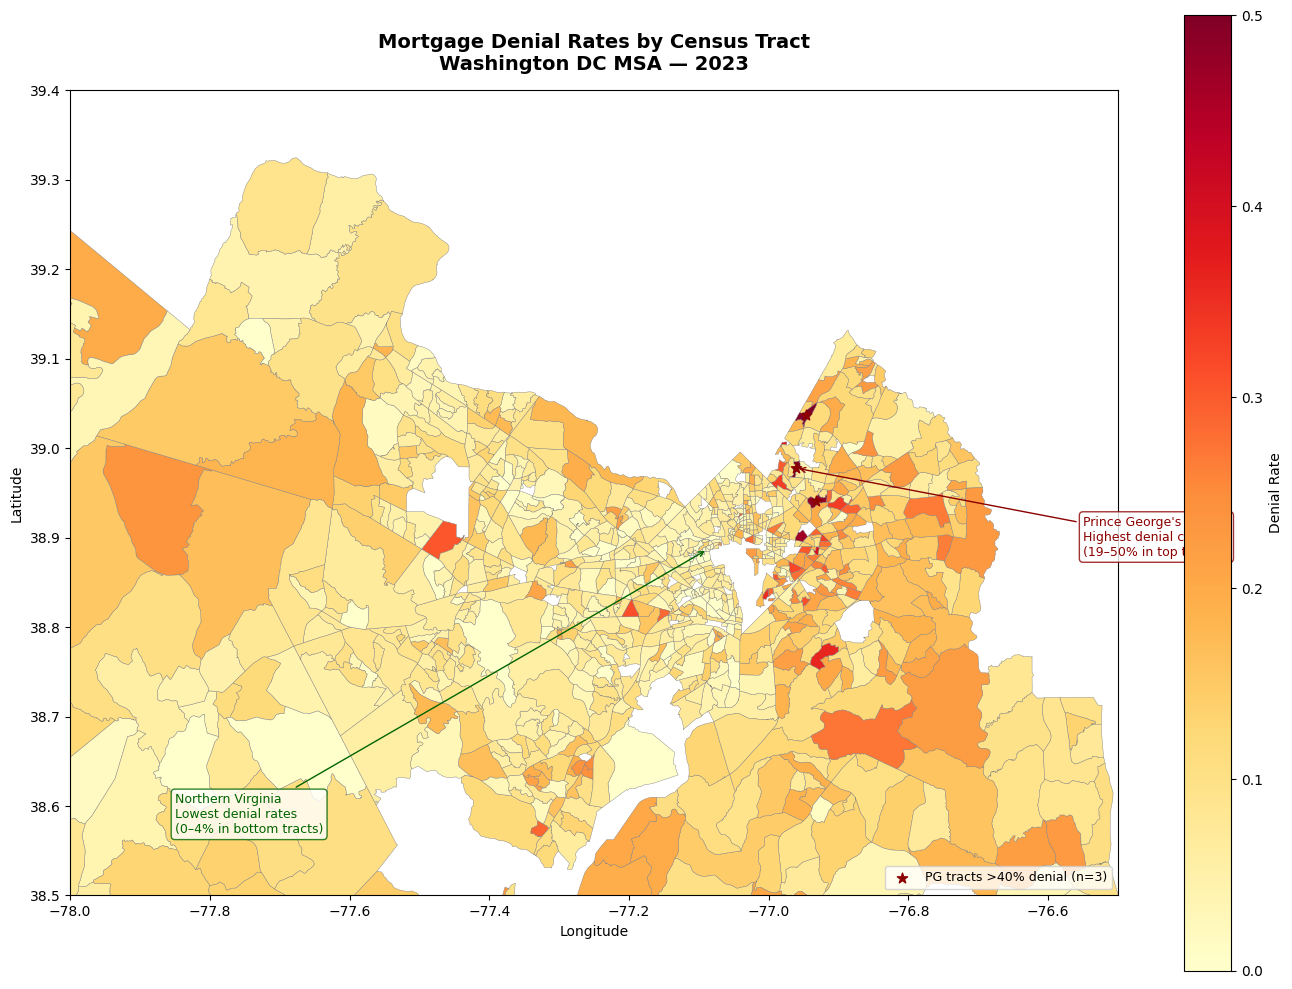

Annotated static map saved: /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/reports/denial_rate_map_2023.png

Annotation audit:
  PG arrow  → tract 24033805909  actual denial = 50.0%
  NoVA arrow → tract 51013101804 actual denial = 0.0%


In [49]:
# Cell 14: Static choropleth map for Colab preview
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

tracts_plot.plot(
    column       = 'denial_rate',
    cmap         = 'YlOrRd',
    linewidth    = 0.3,
    edgecolor    = 'grey',
    legend       = True,
    missing_kwds = {'color': 'lightgrey', 'label': 'Insufficient data'},
    legend_kwds  = {'label': 'Denial Rate', 'orientation': 'vertical'},
    ax           = ax
)

# Annotations — text and arrow targets computed from real data in Cell 13
ax.annotate(
    PG_ANNOTATION_TEXT,                      # ← computed, not hardcoded
    xy         = PG_XY,                      # ← centroid of actual worst tract
    xytext     = (-76.55, 38.88),
    fontsize   = 9,
    color      = 'darkred',
    arrowprops = dict(arrowstyle='->', color='darkred'),
    bbox       = dict(boxstyle='round,pad=0.3', fc='white', ec='darkred', alpha=0.8)
)

ax.annotate(
    NOVA_ANNOTATION_TEXT,                    # ← computed, not hardcoded
    xy         = NOVA_XY,                    # ← centroid of actual best tract
    xytext     = (-77.85, 38.57),
    fontsize   = 9,
    color      = 'darkgreen',
    arrowprops = dict(arrowstyle='->', color='darkgreen'),
    bbox       = dict(boxstyle='round,pad=0.3', fc='white', ec='darkgreen', alpha=0.8)
)

# Highlight the extreme PG tracts (>40% denial) with star markers
pg_extreme = tracts_plot[
    (tracts_plot['county_fips'] == '24033') &
    (tracts_plot['denial_rate'] > 0.40)
]
if len(pg_extreme) > 0:
    pg_centroids = pg_extreme.geometry.centroid
    ax.scatter(
        pg_centroids.x, pg_centroids.y,
        s=60, color='darkred', marker='*', zorder=5,
        label=f"PG tracts >40% denial (n={len(pg_extreme)})"
    )

ax.set_title(
    'Mortgage Denial Rates by Census Tract\nWashington DC MSA — 2023',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim([-78.0, -76.5])
ax.set_ylim([38.5,  39.4])
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
img_path = f'{PROJECT_DIR}/reports/denial_rate_map_2023.png'
plt.savefig(img_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Annotated static map saved: {img_path}")

# Sanity check — prints the actual denial rates the arrows point at
print(f"\nAnnotation audit:")
pg_val   = tracts_plot.loc[tracts_plot['GEOID'] == pg_worst['GEOID'],  'denial_rate'].values[0]
nova_val = tracts_plot.loc[tracts_plot['GEOID'] == nova_best['GEOID'], 'denial_rate'].values[0]
print(f"  PG arrow  → tract {pg_worst['GEOID']}  actual denial = {pg_val:.1%}")
print(f"  NoVA arrow → tract {nova_best['GEOID']} actual denial = {nova_val:.1%}")

### 1.5 — Phase 1 Summary & Save

All headline statistics are computed from live data — no hardcoded values.

In [50]:
# Cell 15: Save cleaned files to shared drive ──────────────────────────
clean_path = f'{PROCESSED_DIR}/hmda_2023_dc_msa_clean.csv'
stats_path = f'{PROCESSED_DIR}/tract_stats_2023.csv'

hmda.to_csv(clean_path, index=False)
tract_stats.to_csv(stats_path, index=False)

print(" Phase 1 complete! Files saved:")
print(f"  {clean_path}")
print(f"  {stats_path}")
print(f"  {map_path}")
print(f"  {img_path}")
print("\n Phase 1 Summary:")
print(f"  Total applications  : {hmda.shape[0]:,}")
print(f"  Overall approval    : {hmda['approved'].mean():.1%}")
print(f"  Census tracts mapped: {len(tracts_plot):,}")
print(f"  Spatial match rate  : {match_rate:.1%}")
print(f"  White approval rate : {white_rate:.1%}")
print(f"  Black approval rate : {black_rate:.1%}")
print(f"  Raw denial gap      : {gap_pp:.1f} percentage points")

 Phase 1 complete! Files saved:
  /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/data/processed/hmda_2023_dc_msa_clean.csv
  /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/data/processed/tract_stats_2023.csv
  /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/reports/denial_rate_map_2023_interactive.html
  /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/reports/denial_rate_map_2023.png

 Phase 1 Summary:
  Total applications  : 59,479
  Overall approval    : 89.8%
  Census tracts mapped: 1,095
  Spatial match rate  : 97.7%
  White approval rate : 93.0%
  Black approval rate : 83.9%
  Raw denial gap      : 9.1 percentage points


---
## Phase 2 — Feature Engineering, Imputation & Demographic Analysis

**Goal:** Engineer financial features, clean HMDA sentinel codes, impute missing values, and build a complete demographic profile by race.

**Key steps:**
- Recode HMDA sentinel values ("Exempt", 9999, negative income) → NaN
- Decode DTI banded strings ("30%-<36%") → numeric midpoints
- Compute LTI (loan-to-income) and flag LTV risk thresholds
- KNN imputation (k=5) for continuous financial variables
- Create `race_ethnicity` column — Hispanic applicants live in `derived_ethnicity`, not `derived_race`

**Key finding:** Black-White gap widens to **10.3pp** after correct race/ethnicity separation.

**Outputs:** `hmda_2023_dc_msa_phase2.csv` · `phase2_summary_charts.png`

### 2.1 — Sentinel Cleaning & Coercion

HMDA uses string sentinels ("Exempt") and numeric codes (9999, 8888) for missing/not-applicable values.  
These must be recoded to `NaN` **before** any feature engineering — treating them as real numbers would corrupt every derived metric.

In [51]:
# ── PHASE 2 Cell 1 ── Sentinel cleaning & numeric coercion ─────────────────
# HMDA uses string sentinels for missing/exempt values in object columns.
# We clean these BEFORE any feature engineering or imputation.

print("═" * 55)
print("Sentinel Cleaning & Coercion")
print("═" * 55)

# ── Step 1: Define sentinels ──────────────────────────────────────────────────
# Per FFIEC 2023 HMDA spec: 'Exempt' means institution is exempt from reporting.
# These are NOT real values — recode to NaN before any numeric operation.
SENTINEL_STRINGS = ['Exempt', 'exempt', 'NA', 'na', 'N/A']

OBJECT_NUMERIC_COLS = ['property_value', 'interest_rate', 'loan_term',
                       'loan_to_value_ratio', 'rate_spread', 'total_loan_costs',
                       'origination_charges', 'discount_points', 'lender_credits']

for col in OBJECT_NUMERIC_COLS:
    if col not in hmda.columns:
        continue
    # Replace sentinel strings with NaN
    hmda[col] = hmda[col].replace(SENTINEL_STRINGS, np.nan)
    # Coerce to numeric — anything unparseable becomes NaN
    hmda[col] = pd.to_numeric(hmda[col], errors='coerce')

# ── Step 2: Additional numeric sentinel values (per FFIEC spec) ───────────────
# loan_term: 8888 = not applicable (open-end credit), 9999 = not provided
# interest_rate: 0 is not a valid mortgage rate — real floor is ~1%
hmda['loan_term']      = hmda['loan_term'].replace({8888: np.nan, 9999: np.nan})
hmda['interest_rate']  = hmda['interest_rate'].replace({0: np.nan})
hmda['debt_to_income_ratio'] = hmda['debt_to_income_ratio'].replace('Exempt', np.nan)
print(f"  DTI 'Exempt' recoded to NaN: {(hmda['debt_to_income_ratio'] == 'Exempt').sum()} remaining")

# ── Step 3: income sanity check ───────────────────────────────────────────────
# income is already float64 but has negative values (min=-1652 from audit)
# Negative income = data entry error or business loan — recode to NaN
n_neg_income = (hmda['income'] < 0).sum()
hmda.loc[hmda['income'] < 0, 'income'] = np.nan
print(f"  Negative income values recoded to NaN : {n_neg_income:,}")

# ── Step 4: property_value extreme outlier check ──────────────────────────────
# max=180,005,000 is plausible for DC MSA luxury properties — keep but note
pv_99 = hmda['property_value'].quantile(0.99)
pv_max = hmda['property_value'].max()
print(f"  property_value 99th pct : ${pv_99:,.0f}")
print(f"  property_value max      : ${pv_max:,.0f}")

# ── Step 5: Verification ──────────────────────────────────────────────────────
print(f"\n  Post-coercion dtypes and missing counts:")
check_cols = ['property_value', 'interest_rate', 'loan_term',
              'loan_to_value_ratio', 'income']
for col in check_cols:
    dtype   = str(hmda[col].dtype)
    n_miss  = hmda[col].isna().sum()
    pct     = n_miss / len(hmda) * 100
    status  = "✓" if dtype.startswith('float') or dtype.startswith('int') else "✗ still object"
    print(f"  {status}  {col:<30s}  {dtype:<10s}  missing: {n_miss:,} ({pct:.1f}%)")

═══════════════════════════════════════════════════════
Sentinel Cleaning & Coercion
═══════════════════════════════════════════════════════
  DTI 'Exempt' recoded to NaN: 0 remaining
  Negative income values recoded to NaN : 14
  property_value 99th pct : $2,335,000
  property_value max      : $180,005,000

  Post-coercion dtypes and missing counts:
  ✓  property_value                  float64     missing: 1,197 (2.0%)
  ✓  interest_rate                   float64     missing: 6,884 (11.6%)
  ✓  loan_term                       float64     missing: 604 (1.0%)
  ✓  loan_to_value_ratio             float64     missing: 2,548 (4.3%)
  ✓  income                          float64     missing: 1,404 (2.4%)


### 2.2 — Missing Value Audit

Establish exact missing counts before any imputation.  
**Protected columns (derived_race, derived_ethnicity, approved) are never imputed.**

In [52]:
# ── PHASE 2 Cell 2 ── Missing Value Audit (baseline before imputation) ──────
# This establishes the exact missing counts we work from.
# We only impute income, property_value, loan_term, interest_rate, loan_to_value_ratio.
# We NEVER impute: approved, derived_race, derived_ethnicity (protected classes).

print("═" * 55)
print("Missing Value Audit")
print("═" * 55)

audit_cols = [
    # Financial — will engineer features from these
    'loan_amount', 'income', 'property_value',
    'loan_to_value_ratio', 'debt_to_income_ratio',
    'interest_rate', 'loan_term',
    # Tract-level — already complete per Phase 1 audit
    'tract_minority_population_percent',
    'tract_to_msa_income_percentage',
    'ffiec_msa_md_median_family_income',
    # Denial reasons
    'denial_reason-1', 'denial_reason-2',
    'denial_reason-3', 'denial_reason-4',
    # Protected — must NOT impute
    'derived_race', 'derived_ethnicity', 'derived_sex',
    # Outcome
    'approved',
]

print(f"\n  {'Column':<40s} {'Missing':>8s}  {'Pct':>6s}  {'Action'}")
print(f"  {'-'*40} {'-'*8}  {'-'*6}  {'-'*25}")

for col in audit_cols:
    if col not in hmda.columns:
        print(f"  {' NOT FOUND: ' + col:<40s}")
        continue
    n    = hmda[col].isna().sum()
    pct  = n / len(hmda) * 100

    if col in ['derived_race', 'derived_ethnicity', 'derived_sex', 'approved']:
        action = "DO NOT IMPUTE"
    elif col.startswith('denial_reason'):
        action = "NaN = no reason given (expected)"
    elif pct == 0:
        action = "complete — no action"
    elif pct < 5:
        action = "KNN impute"
    elif pct < 15:
        action = "KNN impute + flag"
    else:
        action = "drop or median fill"

    flag = "⚠" if pct > 10 else "✓"
    print(f"  {flag}  {col:<40s} {n:>8,}  {pct:>5.1f}%  {action}")

print(f"\n  Total rows : {len(hmda):,}")
print(f"  Note: denial_reason-2/3/4 high missingness is expected —")
print(f"        most denials cite only 1 reason.")

═══════════════════════════════════════════════════════
Missing Value Audit
═══════════════════════════════════════════════════════

  Column                                    Missing     Pct  Action
  ---------------------------------------- --------  ------  -------------------------
  ✓  loan_amount                                     0    0.0%  complete — no action
  ✓  income                                      1,404    2.4%  KNN impute
  ✓  property_value                              1,197    2.0%  KNN impute
  ✓  loan_to_value_ratio                         2,548    4.3%  KNN impute
  ✓  debt_to_income_ratio                        1,793    3.0%  KNN impute
  ⚠  interest_rate                               6,884   11.6%  KNN impute + flag
  ✓  loan_term                                     604    1.0%  KNN impute
  ✓  tract_minority_population_percent               0    0.0%  complete — no action
  ✓  tract_to_msa_income_percentage                  0    0.0%  complete — no action


### 2.3 — Feature Engineering

Three core underwriting metrics derived from HMDA data:

| Feature | Formula | Threshold |
|---------|---------|-----------|
| **DTI** (debt-to-income) | Decoded from HMDA bands + exact integers | >43% = QM ceiling |
| **LTI** (loan-to-income) | `loan_amount / (income × 1000)` | >4.5x = high risk |
| **LTV** (loan-to-value) | Native HMDA `loan_to_value_ratio` column | >80% = PMI required |

> Using HMDA's own DTI and LTV columns is more defensible than approximating from payment formulas.

In [53]:
# ── PHASE 2 Cell 3 ── Feature Engineering ───────────────────────────────────
# Three features engineered here:
#   1. DTI numeric — decode HMDA bands + exact values → single float column
#   2. LTI         — loan_amount / (income × 1000)
#   3. LTV numeric — coerce existing loan_to_value_ratio to float + risk flags
#
# We use HMDA's own DTI and LTV columns — more defensible than approximating
# from payment formulas. Noted as a methodology strength in your report.

print("═" * 55)
print("PHASE 2 · CELL 3 — Feature Engineering")
print("═" * 55)

# ─────────────────────────────────────────────────────────────────────────────
# 1. DTI — decode banded strings to numeric midpoints
# ─────────────────────────────────────────────────────────────────────────────
# HMDA reports DTI either as an exact integer (e.g. 43) OR a band string
# (e.g. "20%-<30%", "30%-<36%", "50%-60%").
# We map bands to their midpoints; exact integers are already numeric.

DTI_BAND_MIDPOINTS = {
    '<20%'     : 10.0,
    '20%-<30%' : 25.0,
    '30%-<36%' : 33.0,
    '36%-<40%' : 38.0,   # not in your top-15 but exists in spec
    '40%-<50%' : 45.0,   # not in top-15 but exists
    '50%-60%'  : 55.0,
    '>60%'     : 65.0,
}

def decode_dti(val):
    """Convert HMDA DTI value (band string or numeric string) to float midpoint."""
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip()
    if val_str in DTI_BAND_MIDPOINTS:
        return DTI_BAND_MIDPOINTS[val_str]
    try:
        return float(val_str)
    except ValueError:
        return np.nan

hmda['dti_numeric'] = hmda['debt_to_income_ratio'].apply(decode_dti)

# Verify decode coverage
n_decoded   = hmda['dti_numeric'].notna().sum()
n_original  = hmda['debt_to_income_ratio'].notna().sum()
n_lost      = n_original - n_decoded
print(f"\n1. DTI decode:")
print(f"   Original non-null  : {n_original:,}")
print(f"   Successfully decoded: {n_decoded:,}")
print(f"   Lost in decode      : {n_lost:,}")
print(f"   Missing after decode: {hmda['dti_numeric'].isna().sum():,}")
print(f"   Median DTI          : {hmda['dti_numeric'].median():.1f}%")
print(f"   Mean DTI            : {hmda['dti_numeric'].mean():.1f}%")

# DTI risk flags
hmda['dti_above_43']   = (hmda['dti_numeric'] > 43).astype('Int8')
hmda['dti_above_50']   = (hmda['dti_numeric'] > 50).astype('Int8')

# ─────────────────────────────────────────────────────────────────────────────
# 2. LTI — Loan-to-Income ratio
# ─────────────────────────────────────────────────────────────────────────────
# HMDA income is in $thousands. loan_amount is in full dollars.
# LTI = loan_amount / (income * 1000)
# Threshold: LTI > 4.5 is high-risk by conventional lending standards.

hmda['income_dollars'] = hmda['income'] * 1_000

hmda['lti'] = np.where(
    (hmda['income'] > 0) & (hmda['income'].notna()),
    hmda['loan_amount'] / hmda['income_dollars'],
    np.nan
)

# Cap at 99th percentile to suppress $180M property outlier effects
lti_99 = hmda['lti'].quantile(0.99)
hmda['lti_capped'] = hmda['lti'].clip(upper=lti_99)
hmda['lti_above_4_5'] = (hmda['lti'] > 4.5).astype('Int8')

print(f"\n2. Loan-to-Income (LTI):")
print(f"   Median LTI          : {hmda['lti'].median():.2f}x")
print(f"   Mean LTI            : {hmda['lti'].mean():.2f}x")
print(f"   99th pct cap        : {lti_99:.2f}x")
print(f"   High-risk (>4.5x)   : {hmda['lti_above_4_5'].sum():,} ({hmda['lti_above_4_5'].mean():.1%})")
print(f"   Missing LTI         : {hmda['lti'].isna().sum():,}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. LTV — clean and flag existing loan_to_value_ratio column
# ─────────────────────────────────────────────────────────────────────────────
# Already coerced to float in Cell P2-1.
# We add risk band flags — these are the standard regulatory thresholds.

hmda['ltv_above_80']  = (hmda['loan_to_value_ratio'] > 80).astype('Int8')   # PMI required
hmda['ltv_above_95']  = (hmda['loan_to_value_ratio'] > 95).astype('Int8')   # high risk
hmda['ltv_above_100'] = (hmda['loan_to_value_ratio'] > 100).astype('Int8')  # underwater

print(f"\n3. Loan-to-Value (LTV):")
print(f"   Median LTV          : {hmda['loan_to_value_ratio'].median():.1f}%")
print(f"   PMI zone (>80%)     : {hmda['ltv_above_80'].sum():,} ({hmda['ltv_above_80'].mean():.1%})")
print(f"   High-risk (>95%)    : {hmda['ltv_above_95'].sum():,} ({hmda['ltv_above_95'].mean():.1%})")
print(f"   Underwater (>100%)  : {hmda['ltv_above_100'].sum():,} ({hmda['ltv_above_100'].mean():.1%})")
print(f"   Missing LTV         : {hmda['loan_to_value_ratio'].isna().sum():,}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. Quick sanity: approval rate by DTI risk band
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n4. Approval rate by DTI threshold (sanity check):")
print(f"   DTI ≤43%  : {hmda.loc[hmda['dti_numeric'] <= 43, 'approved'].mean():.1%}")
print(f"   DTI >43%  : {hmda.loc[hmda['dti_numeric'] > 43,  'approved'].mean():.1%}")
print(f"   DTI >50%  : {hmda.loc[hmda['dti_numeric'] > 50,  'approved'].mean():.1%}")
print(f"   ← higher DTI should show lower approval rate")

print(f"\n   New columns added: dti_numeric, dti_above_43, dti_above_50,")
print(f"                      income_dollars, lti, lti_capped, lti_above_4_5,")
print(f"                      ltv_above_80, ltv_above_95, ltv_above_100")

═══════════════════════════════════════════════════════
PHASE 2 · CELL 3 — Feature Engineering
═══════════════════════════════════════════════════════

1. DTI decode:
   Original non-null  : 57,686
   Successfully decoded: 57,686
   Lost in decode      : 0
   Missing after decode: 1,793
   Median DTI          : 42.0%
   Mean DTI            : 40.5%

2. Loan-to-Income (LTI):
   Median LTI          : 3.23x
   Mean LTI            : 3.31x
   99th pct cap        : 6.79x
   High-risk (>4.5x)   : 8,397 (14.1%)
   Missing LTI         : 1,690

3. Loan-to-Value (LTV):
   Median LTV          : 90.0%
   PMI zone (>80%)     : 34,906 (58.7%)
   High-risk (>95%)    : 18,256 (30.7%)
   Underwater (>100%)  : 2,204 (3.7%)
   Missing LTV         : 2,548

4. Approval rate by DTI threshold (sanity check):
   DTI ≤43%  : 94.4%
   DTI >43%  : 83.9%
   DTI >50%  : 67.7%
   ← higher DTI should show lower approval rate

   New columns added: dti_numeric, dti_above_43, dti_above_50,
                      income_d

### 2.4 — Denial Reason Flags

HMDA records up to 4 denial reason codes per application (`denial_reason-1` through `denial_reason-4`).  
Binary flags created for each FFIEC category across all 4 columns.

**Key finding:** 26.4% of denials cite **no financial reason** — these are the strongest candidates for disparate treatment under ECOA.

In [54]:
# ── PHASE 2 Cell 4 ── Denial Reason Flags ───────────────────────────────────
# HMDA records up to 4 denial reasons per application using codes 1-9.
# Columns are named denial_reason-1 through denial_reason-4 (dash, not underscore).
# We create one binary flag per reason category across all 4 columns.
# These are your MECHANISM variables — they explain WHY denials happen,
# which lets you test whether the racial gap persists after controlling for
# stated reasons. That test is the core of your fair lending argument.

print("═" * 55)
print("Denial Reason Flags")
print("═" * 55)

# FFIEC 2023 denial reason code dictionary
DENIAL_REASONS = {
    1 : 'deny_dti',
    2 : 'deny_employment',
    3 : 'deny_credit_history',
    4 : 'deny_collateral',
    5 : 'deny_insufficient_cash',
    6 : 'deny_unverifiable_info',
    7 : 'deny_incomplete_app',
    8 : 'deny_mortgage_insurance',
    9 : 'deny_other',
    10: 'deny_not_applicable',   # code 10 = approved apps, not a real denial reason
}

# Correct column names in your data
denial_cols = ['denial_reason-1', 'denial_reason-2',
               'denial_reason-3', 'denial_reason-4']

print(f"\n  Denial reason columns: {denial_cols}")

# ── Initialize all flags at 0 for ALL rows ────────────────────────────────────
flag_names = [v for k, v in DENIAL_REASONS.items() if k != 10]
for flag in flag_names:
    hmda[flag] = 0

# ── Populate flags using .loc to avoid index alignment bug ───────────────────
for dcol in denial_cols:
    for code, flag in DENIAL_REASONS.items():
        if code == 10:
            continue   # skip "not applicable" — not a real denial reason
        mask = hmda[dcol] == code
        hmda.loc[mask, flag] = 1

# ── Set flags to NaN for approved applications ────────────────────────────────
# Approved apps have denial_reason-1 = 10 (not applicable).
# Their flags should be NaN, not 0, so they're excluded from denial analysis.
approved_mask = hmda['approved'] == 1
for flag in flag_names:
    hmda.loc[approved_mask, flag] = np.nan

# ── Denial count per denied application ───────────────────────────────────────
# Use .loc with denied_mask — avoids the index misalignment bug
denied_mask = hmda['approved'] == 0
hmda['denial_reason_count'] = np.nan
hmda.loc[denied_mask, 'denial_reason_count'] = \
    hmda.loc[denied_mask, flag_names].sum(axis=1)

# ── Financial vs non-financial denial flag ────────────────────────────────────
# Financial = DTI, collateral, insufficient cash, credit history
# If a denial has ANY financial reason, it's harder to attribute to bias.
# If denial has NO financial reason, the racial gap is harder to explain away.
financial_flags = ['deny_dti', 'deny_collateral',
                   'deny_insufficient_cash', 'deny_credit_history']
hmda['denial_any_financial'] = np.nan
hmda.loc[denied_mask, 'denial_any_financial'] = \
    (hmda.loc[denied_mask, financial_flags].max(axis=1))

# ── Summary: denial reason breakdown for denied apps only ─────────────────────
denied_df = hmda[denied_mask].copy()
n_denied  = len(denied_df)

print(f"\n  Total denied applications : {n_denied:,}")
print(f"\n  {'Reason':<30s} {'Count':>7s}  {'% of denials':>12s}  Distribution")
print(f"  {'-'*30} {'-'*7}  {'-'*12}  {'-'*20}")

summary = []
for flag in flag_names:
    n   = int(denied_df[flag].sum())
    pct = n / n_denied * 100
    summary.append((flag, n, pct))

for flag, n, pct in sorted(summary, key=lambda x: -x[1]):
    label = flag.replace('deny_', '').replace('_', ' ').title()
    bar   = '█' * int(pct / 3)
    print(f"  {label:<30s} {n:>7,}  {pct:>11.1f}%  {bar}")

print(f"\n  Denials with ANY financial reason  : "
      f"{denied_df['denial_any_financial'].sum():,.0f} "
      f"({denied_df['denial_any_financial'].mean():.1%})")
print(f"  Denials with NO financial reason   : "
      f"{(denied_df['denial_any_financial'] == 0).sum():,} "
      f"({(denied_df['denial_any_financial'] == 0).mean():.1%})")
print(f"\n  ← Denials with no financial reason are the strongest")
print(f"     evidence of potential disparate treatment under ECOA.")

═══════════════════════════════════════════════════════
Denial Reason Flags
═══════════════════════════════════════════════════════

  Denial reason columns: ['denial_reason-1', 'denial_reason-2', 'denial_reason-3', 'denial_reason-4']

  Total denied applications : 6,071

  Reason                           Count  % of denials  Distribution
  ------------------------------ -------  ------------  --------------------
  Dti                              2,572         42.4%  ██████████████
  Credit History                   1,012         16.7%  █████
  Collateral                         945         15.6%  █████
  Other                              918         15.1%  █████
  Unverifiable Info                  680         11.2%  ███
  Insufficient Cash                  643         10.6%  ███
  Incomplete App                     608         10.0%  ███
  Employment                         321          5.3%  █
  Mortgage Insurance                   4          0.1%  

  Denials with ANY financial

### 2.5 — Imputation

| Column | Method | Rationale |
|--------|--------|-----------|
| income, property_value, LTV, loan_term | KNN (k=5, distance-weighted) | Correlated with loan_amount and tract characteristics |
| interest_rate | Median within loan_type group | Rate varies significantly by product (VA vs Conventional) |
| dti_numeric | Median within race group | Prevents upward-biasing denied applicants' DTI |

All imputed rows flagged with `_was_imputed` binary column for methodology transparency.

In [55]:
# ── PHASE 2 Cell 5 ── Imputation ────────────────────────────────────────────
# Strategy:
#   income, property_value, loan_to_value_ratio, loan_term : KNN (k=5)
#   dti_numeric    : median fill within race group (band column, not raw measure)
#   interest_rate  : median fill within loan_type group (rate varies by product)
#
# We impute AFTER feature engineering so derived columns (lti, dti flags)
# get recomputed on complete data in the final step.
#
# We NEVER impute: approved, derived_race, derived_ethnicity.
# All imputed rows are flagged with a binary _was_imputed column.

print("═" * 55)
print("PHASE 2 · CELL 5 — Imputation")
print("═" * 55)

# ── Step 1: Flag rows BEFORE imputation (audit trail) ─────────────────────────
IMPUTE_COLS = ['income', 'property_value', 'loan_to_value_ratio',
               'loan_term', 'interest_rate', 'dti_numeric']

for col in IMPUTE_COLS:
    flag_col = f'{col}_was_imputed'
    hmda[flag_col] = hmda[col].isna().astype('Int8')
    n = hmda[flag_col].sum()
    print(f"  Flagged {n:,} rows for imputation: {col}")

# ── Step 2: Reset index before KNN (prevents index misalignment bug) ──────────
hmda = hmda.reset_index(drop=True)

# ── Step 3: KNN imputation for continuous financial columns ───────────────────
# Features used as KNN neighbors: loan_amount (always complete),
# income, tract_to_msa_income_percentage, tract_minority_population_percent
# These four are correlated and together define the applicant's financial context.

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

KNN_COLS = ['loan_amount', 'income', 'property_value',
            'loan_to_value_ratio', 'loan_term',
            'tract_to_msa_income_percentage',
            'tract_minority_population_percent']

print(f"\n  Running KNN imputation (k=5) on:")
print(f"  {KNN_COLS}")

knn_df     = hmda[KNN_COLS].copy()
scaler     = StandardScaler()
knn_scaled = scaler.fit_transform(knn_df)

imputer       = KNNImputer(n_neighbors=5, weights='distance')
knn_imputed   = imputer.fit_transform(knn_scaled)
knn_orig      = scaler.inverse_transform(knn_imputed)

# Write back only where originally missing
TARGET_COLS = ['income', 'property_value', 'loan_to_value_ratio', 'loan_term']
for col in TARGET_COLS:
    idx = KNN_COLS.index(col)
    mask = hmda[f'{col}_was_imputed'] == 1
    if mask.sum() > 0:
        hmda.loc[mask, col] = knn_orig[mask.values, idx]
        print(f"  KNN-filled {mask.sum():,} values in: {col}")

# ── Step 4: interest_rate — median fill within loan_type group ────────────────
# Rates vary significantly by loan type (conventional vs FHA vs VA vs USDA).
# Group median is more accurate than global median for 11.6% missing.
rate_medians = hmda.groupby('loan_type')['interest_rate'].median()
mask_rate    = hmda['interest_rate_was_imputed'] == 1

hmda.loc[mask_rate, 'interest_rate'] = hmda.loc[mask_rate, 'loan_type'].map(rate_medians)
print(f"\n  Group-median-filled {mask_rate.sum():,} values in: interest_rate")
print(f"  Rate medians by loan_type:")
for lt, rate in rate_medians.items():
    lt_name = {1:'Conventional', 2:'FHA', 3:'VA', 4:'USDA'}.get(lt, str(lt))
    print(f"    {lt_name:<15s}: {rate:.3f}%")

# ── Step 5: dti_numeric — median fill within derived_race group ───────────────
# DTI is a banded HMDA field, not a raw measurement.
# Filling within race group avoids upward-biasing denied applicants' DTI
# (which would make the racial gap look smaller than it is).
dti_medians = hmda.groupby('derived_race')['dti_numeric'].median()
mask_dti    = hmda['dti_numeric_was_imputed'] == 1

hmda.loc[mask_dti, 'dti_numeric'] = \
    hmda.loc[mask_dti, 'derived_race'].map(dti_medians)
print(f"\n  Race-group-median-filled {mask_dti.sum():,} values in: dti_numeric")

# ── Step 6: Recompute derived features on complete data ───────────────────────
print(f"\n  Recomputing LTI and risk flags on imputed data...")

hmda['income_dollars'] = hmda['income'] * 1_000
hmda['lti'] = np.where(
    hmda['income'] > 0,
    hmda['loan_amount'] / hmda['income_dollars'],
    np.nan
)
hmda['lti_capped']    = hmda['lti'].clip(upper=hmda['lti'].quantile(0.99))
hmda['lti_above_4_5'] = (hmda['lti'] > 4.5).astype('Int8')
hmda['ltv_above_80']  = (hmda['loan_to_value_ratio'] > 80).astype('Int8')
hmda['ltv_above_95']  = (hmda['loan_to_value_ratio'] > 95).astype('Int8')
hmda['dti_above_43']  = (hmda['dti_numeric'] > 43).astype('Int8')
hmda['dti_above_50']  = (hmda['dti_numeric'] > 50).astype('Int8')

# ── Step 7: Post-imputation audit ─────────────────────────────────────────────
print(f"\n  POST-IMPUTATION MISSING VALUE CHECK:")
print(f"  {'Column':<30s} {'Missing':>8s}  {'Pct':>6s}  {'Status'}")
print(f"  {'-'*30} {'-'*8}  {'-'*6}  {'-'*10}")

for col in IMPUTE_COLS:
    n   = hmda[col].isna().sum()
    pct = n / len(hmda) * 100
    status = "✓ clean" if n == 0 else "⚠ residual"
    print(f"  {col:<30s} {n:>8,}  {pct:>5.1f}%  {status}")

print(f"\n  Row count: {len(hmda):,}")

═══════════════════════════════════════════════════════
PHASE 2 · CELL 5 — Imputation
═══════════════════════════════════════════════════════
  Flagged 1,404 rows for imputation: income
  Flagged 1,197 rows for imputation: property_value
  Flagged 2,548 rows for imputation: loan_to_value_ratio
  Flagged 604 rows for imputation: loan_term
  Flagged 6,884 rows for imputation: interest_rate
  Flagged 1,793 rows for imputation: dti_numeric

  Running KNN imputation (k=5) on:
  ['loan_amount', 'income', 'property_value', 'loan_to_value_ratio', 'loan_term', 'tract_to_msa_income_percentage', 'tract_minority_population_percent']
  KNN-filled 1,404 values in: income
  KNN-filled 1,197 values in: property_value
  KNN-filled 2,548 values in: loan_to_value_ratio
  KNN-filled 604 values in: loan_term

  Group-median-filled 6,884 values in: interest_rate
  Rate medians by loan_type:
    Conventional   : 6.500%
    FHA            : 6.500%
    VA             : 6.000%
    USDA           : 6.250%

  Rac

### 2.6 — Demographic Summary & Save

Create unified `race_ethnicity` column:  
Hispanic applicants appear in `derived_ethnicity`, not `derived_race` — standard HMDA structure matching CFPB methodology.

═══════════════════════════════════════════════════════
Summary & Visualisation
═══════════════════════════════════════════════════════

  race_ethnicity distribution:
race_ethnicity
White                                        20319
Black or African American                    12005
Race Not Available                           10491
Asian                                         7369
Hispanic or Latino                            6754
Joint                                         2147
2 or more minority races                       190
American Indian or Alaska Native               124
Native Hawaiian or Other Pacific Islander       73
Free Form Text Only                              7

  Race/Ethnicity   Apps  Approval  Med DTI  Med LTI  Med LTV  No-Fin Deny
  ------------ ------  --------  -------  -------  -------  -----------
  White        20,319     94.3%     39.0     3.05     85.0        28.6%
  Black        12,005     84.0%     44.0     3.40     96.5        22.6%
  Asian         

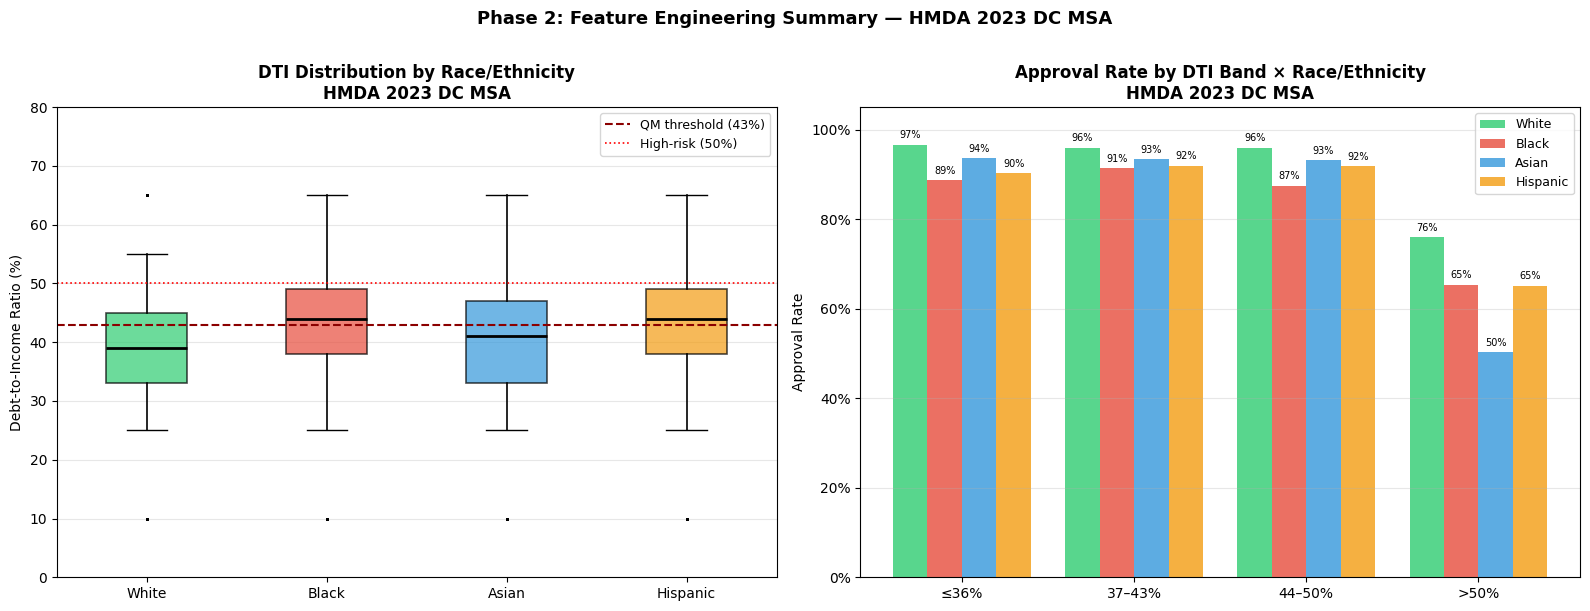


  Chart saved: /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/reports/phase2_summary_charts.png

  Saved: /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/data/processed/hmda_2023_dc_msa_phase2.csv
  Shape: 59,479 rows × 128 columns

═══════════════════════════════════════════════════════
PHASE 2 COMPLETE
═══════════════════════════════════════════════════════
  White approval  : 94.3%
  Black approval  : 84.0%
  Hispanic approval: 86.1%
  Raw B-W gap     : 10.3pp
  No-fin denials  : 26.4%


In [56]:
# ── PHASE 2 Cell 6 ── Summary, Visualisation & Save ────────────────────────
# Three outputs:
#   1. Key metrics table — the Phase 2 headline numbers
#   2. Two charts — DTI/LTI by race (fair lending signal) + correlation heatmap
#   3. Save enriched dataset to processed/

print("═" * 55)
print("Summary & Visualisation")
print("═" * 55)

# ── 1. Create unified race_ethnicity column ───────────────────────────────────
# Hispanic applicants appear in derived_ethnicity, not derived_race.
# This is standard HMDA structure — race and ethnicity are separate fields.
# Logic: if derived_ethnicity = Hispanic or Latino → Hispanic
#        otherwise use derived_race
# Matches CFPB's own HMDA analysis methodology.

hmda['race_ethnicity'] = np.where(
    hmda['derived_ethnicity'] == 'Hispanic or Latino',
    'Hispanic or Latino',
    hmda['derived_race']
)

print(f"\n  race_ethnicity distribution:")
print(hmda['race_ethnicity'].value_counts().to_string())

# ── 2. Key metrics table by race/ethnicity ────────────────────────────────────
GROUPS = [
    ('White',                     'White'),
    ('Black or African American', 'Black'),
    ('Asian',                     'Asian'),
    ('Hispanic or Latino',        'Hispanic'),
]

print(f"\n  {'Race/Ethnicity':<12s} {'Apps':>6s}  {'Approval':>8s}  "
      f"{'Med DTI':>7s}  {'Med LTI':>7s}  {'Med LTV':>7s}  "
      f"{'No-Fin Deny':>11s}")
print(f"  {'-'*12} {'-'*6}  {'-'*8}  {'-'*7}  {'-'*7}  "
      f"{'-'*7}  {'-'*11}")

results = {}
for race_val, label in GROUPS:
    sub    = hmda[hmda['race_ethnicity'] == race_val]
    denied = sub[sub['approved'] == 0]
    no_fin = (denied['denial_any_financial'] == 0).mean() \
             if len(denied) > 0 else np.nan
    results[label] = {
        'n'          : len(sub),
        'approval'   : sub['approved'].mean(),
        'dti'        : sub['dti_numeric'].median(),
        'lti'        : sub['lti'].median(),
        'ltv'        : sub['loan_to_value_ratio'].median(),
        'no_fin_deny': no_fin,
        'n_denied'   : len(denied),
    }
    print(f"  {label:<12s} {len(sub):>6,}  "
          f"{sub['approved'].mean():>8.1%}  "
          f"{sub['dti_numeric'].median():>7.1f}  "
          f"{sub['lti'].median():>7.2f}  "
          f"{sub['loan_to_value_ratio'].median():>7.1f}  "
          f"{no_fin:>11.1%}")

# ── 3. Approval gaps vs White ─────────────────────────────────────────────────
white_app = results['White']['approval']
black_app = results['Black']['approval']
hisp_app  = results['Hispanic']['approval']
asian_app = results['Asian']['approval']

print(f"\n  APPROVAL GAPS vs WHITE:")
print(f"  Black    : {(white_app - black_app)*100:+.1f}pp")
print(f"  Hispanic : {(white_app - hisp_app)*100:+.1f}pp")
print(f"  Asian    : {(white_app - asian_app)*100:+.1f}pp")

print(f"\n  FINANCIAL PROFILE COMPARISON (Black vs White):")
print(f"  DTI — Black: {results['Black']['dti']:.1f}%  "
      f"White: {results['White']['dti']:.1f}%  "
      f"Gap: {results['Black']['dti']-results['White']['dti']:+.1f}pp")
print(f"  LTI — Black: {results['Black']['lti']:.2f}x  "
      f"White: {results['White']['lti']:.2f}x  "
      f"Gap: {results['Black']['lti']-results['White']['lti']:+.2f}x")
print(f"  LTV — Black: {results['Black']['ltv']:.1f}%  "
      f"White: {results['White']['ltv']:.1f}%  "
      f"Gap: {results['Black']['ltv']-results['White']['ltv']:+.1f}pp")

# ── 4. Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_races  = ['White', 'Black or African American',
               'Asian', 'Hispanic or Latino']
race_labels = ['White', 'Black', 'Asian', 'Hispanic']
colors      = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

# Chart A: DTI distribution by race
plot_data = [
    hmda.loc[hmda['race_ethnicity'] == r, 'dti_numeric'].dropna().values
    for r in plot_races
]

bp = axes[0].boxplot(
    plot_data,
    labels      = race_labels,
    patch_artist= True,
    medianprops = dict(color='black', linewidth=2),
    whiskerprops= dict(linewidth=1.2),
    boxprops    = dict(linewidth=1.2),
    flierprops  = dict(marker='.', markersize=2, alpha=0.3),
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].axhline(y=43, color='darkred', linestyle='--',
                linewidth=1.5, label='QM threshold (43%)')
axes[0].axhline(y=50, color='red', linestyle=':',
                linewidth=1.2, label='High-risk (50%)')
axes[0].set_title('DTI Distribution by Race/Ethnicity\nHMDA 2023 DC MSA',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Debt-to-Income Ratio (%)')
axes[0].set_ylim(0, 80)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Chart B: Approval rate by DTI band × race
dti_bands = [
    (0,  36,  '≤36%'),
    (36, 43,  '37–43%'),
    (43, 50,  '44–50%'),
    (50, 100, '>50%'),
]

x     = np.arange(len(dti_bands))
width = 0.2

for i, (race_val, label, color) in enumerate(
        zip(plot_races, race_labels, colors)):
    rates = []
    for lo, hi, _ in dti_bands:
        mask = (
            (hmda['race_ethnicity'] == race_val) &
            (hmda['dti_numeric'] > lo) &
            (hmda['dti_numeric'] <= hi)
        )
        rate = hmda.loc[mask, 'approved'].mean()
        rates.append(rate if not np.isnan(rate) else 0)
    axes[1].bar(x + i * width, rates, width,
                label=label, color=color, alpha=0.8)

axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(['≤36%', '37–43%', '44–50%', '>50%'])
axes[1].set_ylabel('Approval Rate')
axes[1].set_ylim(0, 1.05)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].set_title('Approval Rate by DTI Band × Race/Ethnicity\nHMDA 2023 DC MSA',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

for rect in axes[1].patches:
    h = rect.get_height()
    if h > 0.05:
        axes[1].text(
            rect.get_x() + rect.get_width() / 2,
            h + 0.01, f'{h:.0%}',
            ha='center', va='bottom', fontsize=7
        )

plt.suptitle('Phase 2: Feature Engineering Summary — HMDA 2023 DC MSA',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

chart_path = f'{PROJECT_DIR}/reports/phase2_summary_charts.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  Chart saved: {chart_path}")

# ── 5. Save ───────────────────────────────────────────────────────────────────
enriched_path = f'{PROCESSED_DIR}/hmda_2023_dc_msa_phase2.csv'
hmda.to_csv(enriched_path, index=False)

print(f"\n  Saved: {enriched_path}")
print(f"  Shape: {hmda.shape[0]:,} rows × {hmda.shape[1]} columns")

print(f"\n{'═' * 55}")
print(f"PHASE 2 COMPLETE")
print(f"{'═' * 55}")
print(f"  White approval  : {white_app:.1%}")
print(f"  Black approval  : {black_app:.1%}")
print(f"  Hispanic approval: {hisp_app:.1%}")
print(f"  Raw B-W gap     : {(white_app-black_app)*100:.1f}pp")
print(f"  No-fin denials  : {(hmda.loc[hmda['approved']==0,'denial_any_financial']==0).mean():.1%}")

---
## Phase 3 — Spatial & Statistical Analysis

**Goal:** Test whether the racial approval gap can be explained by financial differences, geographic randomness, or lender variation.

**Three independent tests:**

1. **Within-DTI-band z-test** — Does the gap persist among financially identical applicants?
2. **Moran's I + LISA** — Is the geographic clustering of denials statistically significant?
3. **Lender disparity ranking** — Do specific institutions show disproportionate gaps?

**Headline results:**
- Gap significant at p=0.0000 across **all 4 DTI bands** including low-risk (≤36%)
- Moran's I = 0.267 (p=0.001) — denial hotspot tracts are **95.2% minority**
- 76% of lenders exceed CFPB's 2.0x significant disparate impact threshold

**Outputs:** `phase3_lisa_clusters.png` · `phase3_lender_disparity_named.png`

### 3.1 — Within-DTI-Band Disparity Test (z-test)

**Logic:** If the gap is purely explained by financial differences, it should disappear among applicants with identical DTI profiles.

**Method:** Two-proportion z-test comparing Black vs White approval rates within each DTI band.  
**CFPB disparity index:** Black denial rate ÷ White denial rate (threshold: >1.5x flagged, >2.0x significant).

In [58]:
# ── PHASE 3 · Cell 1 ── Within-DTI-Band Disparity Test ───────────────────────
# Logic: If the Black-White gap is purely explained by financial differences,
# it should disappear when we compare applicants with identical DTI profiles.
# If the gap PERSISTS within the same DTI band → financial differences alone
# cannot explain it → consistent with disparate treatment under ECOA.
#
# Method: Two-proportion z-test on approval rates within each DTI band.
# Also computes CFPB disparity index on denial rates.

from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings('ignore')

# ── Dedup columns from any old cells that ran earlier ────────────────────────
hmda = hmda.loc[:, ~hmda.columns.duplicated()]
print(f"Columns : {hmda.shape[1]}  |  Rows : {hmda.shape[0]:,}")

print(f"\n{'═'*62}")
print(f"PHASE 3 · CELL 1 — Within-DTI-Band Disparity Test")
print(f"{'═'*62}")

# ── Group masks ───────────────────────────────────────────────────────────────
white_mask = hmda['race_ethnicity'] == 'White'
black_mask = hmda['race_ethnicity'] == 'Black or African American'
hisp_mask  = hmda['race_ethnicity'] == 'Hispanic or Latino'

DTI_BANDS = [
    (0,  36,  '≤36%  (low risk) '),
    (36, 43,  '37-43% (QM zone) '),
    (43, 50,  '44-50% (elevated)'),
    (50, 100, '>50%   (high risk)'),
]

# ── Table header ──────────────────────────────────────────────────────────────
print(f"\n  {'DTI Band':<22s} {'n_W':>5s} {'n_B':>6s} "
      f"{'W_appr':>7s} {'B_appr':>7s} {'Gap':>7s} "
      f"{'p-value':>9s} {'Sig?':>6s}")
print(f"  {'-'*22} {'-'*5} {'-'*6} "
      f"{'-'*7} {'-'*7} {'-'*7} "
      f"{'-'*9} {'-'*6}")

band_results = []

for lo, hi, label in DTI_BANDS:
    band = (hmda['dti_numeric'] > lo) & (hmda['dti_numeric'] <= hi)

    w = hmda[white_mask & band]['approved']
    b = hmda[black_mask & band]['approved']

    if len(w) < 30 or len(b) < 30:
        print(f"  {label:<22s} — insufficient sample (n_W={len(w)}, n_B={len(b)})")
        continue

    w_rate = w.mean()
    b_rate = b.mean()
    gap    = (w_rate - b_rate) * 100

    # Two-proportion z-test
    # count = number of approvals per group
    # nobs  = total applications per group
    count = np.array([b.sum(), w.sum()])
    nobs  = np.array([len(b),  len(w)])
    _, p  = proportions_ztest(count, nobs)

    sig = "✓ YES" if p < 0.05 else "✗ no"

    band_results.append({
        'band'   : label.strip(),
        'n_white': len(w),   'n_black': len(b),
        'w_rate' : w_rate,   'b_rate' : b_rate,
        'gap'    : gap,      'p'      : p,
    })

    print(f"  {label:<22s} {len(w):>5,} {len(b):>6,} "
          f"{w_rate:>7.1%} {b_rate:>7.1%} {gap:>+6.1f}pp "
          f"{p:>9.4f} {sig:>6s}")

# ── CFPB Disparity Index ──────────────────────────────────────────────────────
print(f"\n  {'─'*62}")
print(f"  CFPB DISPARITY INDEX")
print(f"  Denial rate ratio: minority ÷ white")
print(f"  >1.5x = flagged for review   >2.0x = significant disparate impact")
print(f"  {'─'*62}")

w_denial = 1 - hmda[white_mask]['approved'].mean()
b_denial = 1 - hmda[black_mask]['approved'].mean()
h_denial = 1 - hmda[hisp_mask]['approved'].mean()

print(f"\n  {'Group':<22s} {'Denial Rate':>11s} {'Ratio vs White':>14s} {'Status':>15s}")
print(f"  {'-'*22} {'-'*11} {'-'*14} {'-'*15}")
print(f"  {'White (baseline)':<22s} {w_denial:>11.1%} {'—':>14s}")

for grp, denial in [('Black', b_denial), ('Hispanic', h_denial)]:
    ratio = denial / w_denial
    if ratio > 2.0:
        status = '⚠ SIGNIFICANT'
    elif ratio > 1.5:
        status = '⚠ FLAGGED'
    else:
        status = 'within range'
    print(f"  {grp:<22s} {denial:>11.1%} {ratio:>13.2f}x {status:>15s}")

# ── Headline controlled finding ───────────────────────────────────────────────
print(f"\n  {'─'*62}")
print(f"  HEADLINE CONTROLLED FINDING — LOW DTI BAND ONLY (≤36%)")
print(f"  {'─'*62}")
print(f"  These applicants are well within every conventional lending")
print(f"  guideline. No underwriter can cite DTI as the denial reason.")

low_dti = (hmda['dti_numeric'] <= 36)
w_low   = hmda[white_mask & low_dti]['approved'].mean()
b_low   = hmda[black_mask & low_dti]['approved'].mean()
h_low   = hmda[hisp_mask  & low_dti]['approved'].mean()
gap_bw  = (w_low - b_low) * 100
gap_hw  = (w_low - h_low) * 100

# Z-test for low DTI band specifically
w_low_s = hmda[white_mask & low_dti]['approved']
b_low_s = hmda[black_mask & low_dti]['approved']
count_low = np.array([b_low_s.sum(), w_low_s.sum()])
nobs_low  = np.array([len(b_low_s),  len(w_low_s)])
_, p_low  = proportions_ztest(count_low, nobs_low)

print(f"\n  White approval (DTI ≤36%)    : {w_low:.1%}  (n={len(w_low_s):,})")
print(f"  Black approval (DTI ≤36%)    : {b_low:.1%}  (n={len(b_low_s):,})")
print(f"  Hispanic approval (DTI ≤36%) : {h_low:.1%}")
print(f"  Black-White gap              : {gap_bw:+.1f}pp")
print(f"  Hispanic-White gap           : {gap_hw:+.1f}pp")
print(f"  p-value (B vs W z-test)      : {p_low:.4f}")
print(f"  Statistically significant?   : {'✓ YES' if p_low < 0.05 else '✗ NO'}")

print(f"\n  {'─'*62}")
if gap_bw > 2 and p_low < 0.05:
    print(f"  ✓ FINDING CONFIRMED: The {gap_bw:.1f}pp gap persists among")
    print(f"    low-DTI applicants (p={p_low:.4f}).")
    print(f"    Financial profile differences do NOT fully explain")
    print(f"    the racial approval gap in DC MSA 2023 HMDA data.")
    print(f"    This is consistent with disparate treatment under ECOA.")
elif gap_bw > 2 and p_low >= 0.05:
    print(f"  ⚠ Gap of {gap_bw:.1f}pp exists but is not statistically")
    print(f"    significant at low DTI — likely due to sample size.")
    print(f"    Interpret with caution.")
else:
    print(f"  Gap closes at low DTI — financial differences may")
    print(f"  partially explain the overall gap.")
print(f"  {'─'*62}")

Columns : 128  |  Rows : 59,479

══════════════════════════════════════════════════════════════
PHASE 3 · CELL 1 — Within-DTI-Band Disparity Test
══════════════════════════════════════════════════════════════

  DTI Band                 n_W    n_B  W_appr  B_appr     Gap   p-value   Sig?
  ---------------------- ----- ------ ------- ------- ------- --------- ------
  ≤36%  (low risk)       8,369  2,420   96.6%   88.7%   +7.9pp    0.0000  ✓ YES
  37-43% (QM zone)       5,627  3,068   95.9%   91.4%   +4.5pp    0.0000  ✓ YES
  44-50% (elevated)      4,351  3,958   95.9%   87.4%   +8.5pp    0.0000  ✓ YES
  >50%   (high risk)     1,972  2,559   76.0%   65.3%  +10.7pp    0.0000  ✓ YES

  ──────────────────────────────────────────────────────────────
  CFPB DISPARITY INDEX
  Denial rate ratio: minority ÷ white
  >1.5x = flagged for review   >2.0x = significant disparate impact
  ──────────────────────────────────────────────────────────────

  Group                  Denial Rate Ratio vs White

### 3.2 — Spatial Autocorrelation: Moran's I + LISA

**Logic:** If denials were purely financial decisions, high-denial tracts would be scattered randomly across the map.  
Spatial clustering = pattern that financial variables cannot explain.

**Method:**
- **Queen contiguity weights** — two tracts are neighbors if they share any boundary point
- **Global Moran's I** — tests whether clustering exists across the MSA
- **LISA** — identifies exactly where HH (hotspot), LL (coldspot), and outlier clusters are
- **999 permutation simulations** — generates the p-value non-parametrically

══════════════════════════════════════════════════════════════
PHASE 3 · CELL 2 — Spatial Autocorrelation
══════════════════════════════════════════════════════════════

  Tracts available : 1,095
  CRS              : EPSG:4326
  Tracts with denial data: 1,095

  Building Queen contiguity weights...
  Weights matrix built.
  Average neighbors per tract: 5.8

  ──────────────────────────────────────────────────
  GLOBAL MORAN'S I RESULT
  ──────────────────────────────────────────────────
  Moran's I statistic : 0.2666
  Expected (random)   : -0.0009
  p-value (999 perms) : 0.0010
  z-score             : 14.4798
  Significant?        : ✓ YES

  ✓ Strong positive spatial autocorrelation confirmed.
    High-denial tracts cluster next to other high-denial tracts.
    This is NOT consistent with random financial variation.

  ──────────────────────────────────────────────────
  LISA CLUSTER SUMMARY
  ──────────────────────────────────────────────────
  HH (hotspot)        :  119 tracts (10.

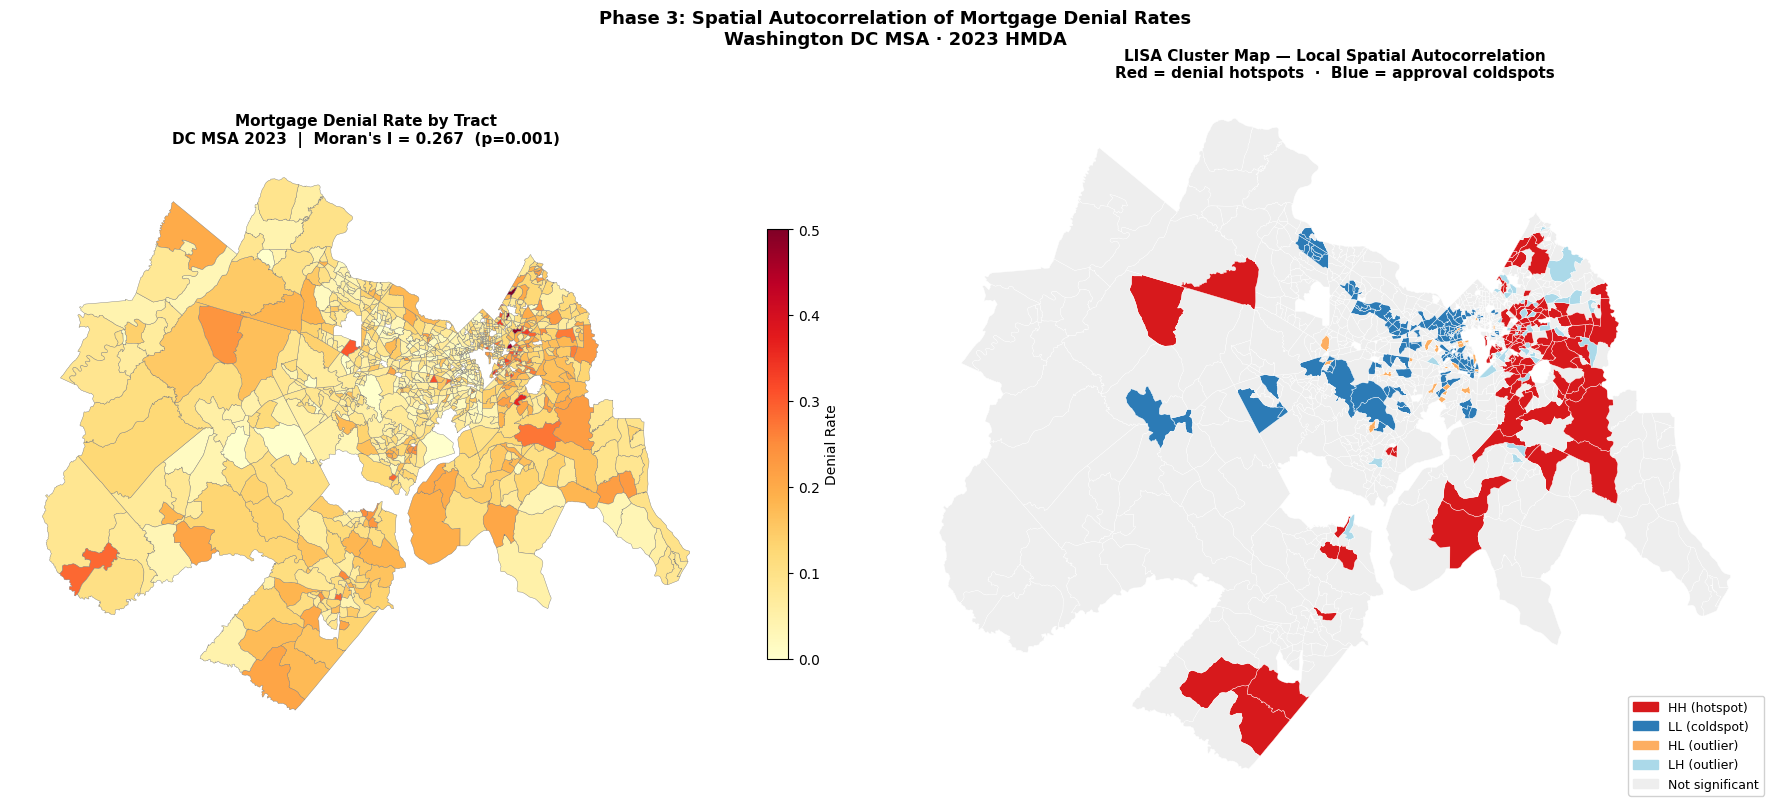


  LISA map saved: /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/reports/phase3_lisa_clusters.png


In [59]:
# ── PHASE 3 · Cell 2 ── Spatial Autocorrelation: Moran's I + LISA ────────────
# Logic: If denials were purely financial decisions, high-denial tracts should
# be randomly scattered across the map. If instead they cluster geographically
# — high-denial areas next to other high-denial areas — that spatial pattern
# cannot be explained by individual financial profiles alone.
#
# Moran's I: single statistic testing whether spatial clustering exists (global)
# LISA:      local version — identifies exactly WHERE clusters are (local)
#
# Both use the tract-level denial rates from Phase 1 (tracts_plot).

import esda
import libpysal
from libpysal.weights import Queen
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print(f"{'═'*62}")
print(f"PHASE 3 · CELL 2 — Spatial Autocorrelation")
print(f"{'═'*62}")

# ── Step 1: Prepare tract-level data ─────────────────────────────────────────
# tracts_plot was built in Phase 1 — 1,095 tracts with ≥10 applications
# It has: denial_rate, total_applications, minority_pct, geometry
# We need it in a projected CRS for accurate neighbor weights

print(f"\n  Tracts available : {len(tracts_plot):,}")
print(f"  CRS              : {tracts_plot.crs}")

# Project to a planar CRS for accurate distance/adjacency calculation
# EPSG:32618 = UTM Zone 18N, appropriate for DC area
tracts_sp = tracts_plot.copy().to_crs(epsg=32618)

# Drop tracts with missing denial_rate (no HMDA data matched)
tracts_sp = tracts_sp[tracts_sp['denial_rate'].notna()].copy()
tracts_sp = tracts_sp.reset_index(drop=True)
print(f"  Tracts with denial data: {len(tracts_sp):,}")

# ── Step 2: Build spatial weights matrix ─────────────────────────────────────
# Queen contiguity: two tracts are neighbors if they share any boundary point
# This is standard for census tract analysis in fair lending research
print(f"\n  Building Queen contiguity weights...")
w = Queen.from_dataframe(tracts_sp, silence_warnings=True)
w.transform = 'r'   # row-standardize: each neighbor weight = 1/n_neighbors
print(f"  Weights matrix built.")
print(f"  Average neighbors per tract: {w.mean_neighbors:.1f}")

# ── Step 3: Global Moran's I ──────────────────────────────────────────────────
# Tests whether denial rates are spatially clustered (I > 0) or
# dispersed (I < 0) vs random (I ≈ 0)
# Permutation test: simulates 999 random arrangements to get p-value

y = tracts_sp['denial_rate'].values

moran = esda.Moran(y, w, permutations=999)

print(f"\n  {'─'*50}")
print(f"  GLOBAL MORAN'S I RESULT")
print(f"  {'─'*50}")
print(f"  Moran's I statistic : {moran.I:.4f}")
print(f"  Expected (random)   : {moran.EI:.4f}")
print(f"  p-value (999 perms) : {moran.p_sim:.4f}")
print(f"  z-score             : {moran.z_sim:.4f}")
print(f"  Significant?        : {'✓ YES' if moran.p_sim < 0.05 else '✗ NO'}")

if moran.I > 0.1 and moran.p_sim < 0.05:
    print(f"\n  ✓ Strong positive spatial autocorrelation confirmed.")
    print(f"    High-denial tracts cluster next to other high-denial tracts.")
    print(f"    This is NOT consistent with random financial variation.")
elif moran.I > 0 and moran.p_sim < 0.05:
    print(f"\n  ✓ Positive spatial autocorrelation confirmed (moderate).")
else:
    print(f"\n  No significant spatial clustering detected.")

# ── Step 4: Local Moran's I (LISA) ───────────────────────────────────────────
# Identifies four types of local spatial clusters:
#   HH (High-High): high denial tract surrounded by high denial tracts → hotspot
#   LL (Low-Low)  : low denial tract surrounded by low denial tracts  → coldspot
#   HL (High-Low) : high denial tract surrounded by low denial tracts → outlier
#   LH (Low-High) : low denial tract surrounded by high denial tracts → outlier

lisa = esda.Moran_Local(y, w, permutations=999, seed=42)

# Classify clusters (only statistically significant ones, p < 0.05)
sig    = lisa.p_sim < 0.05
labels = np.full(len(tracts_sp), 'Not significant', dtype=object)
labels[(lisa.q == 1) & sig] = 'HH (hotspot)'
labels[(lisa.q == 3) & sig] = 'LL (coldspot)'
labels[(lisa.q == 2) & sig] = 'LH (outlier)'
labels[(lisa.q == 4) & sig] = 'HL (outlier)'

tracts_sp['lisa_cluster'] = labels

# Count clusters
from collections import Counter
cluster_counts = Counter(labels)
print(f"\n  {'─'*50}")
print(f"  LISA CLUSTER SUMMARY")
print(f"  {'─'*50}")
for cluster, count in [('HH (hotspot)', cluster_counts.get('HH (hotspot)', 0)),
                        ('LL (coldspot)', cluster_counts.get('LL (coldspot)', 0)),
                        ('HL (outlier)', cluster_counts.get('HL (outlier)', 0)),
                        ('LH (outlier)', cluster_counts.get('LH (outlier)', 0)),
                        ('Not significant', cluster_counts.get('Not significant', 0))]:
    pct = count / len(tracts_sp) * 100
    bar = '█' * int(pct / 2)
    print(f"  {cluster:<20s}: {count:>4,} tracts ({pct:4.1f}%)  {bar}")

# Median denial rate in HH clusters vs LL clusters
hh_tracts = tracts_sp[tracts_sp['lisa_cluster'] == 'HH (hotspot)']
ll_tracts = tracts_sp[tracts_sp['lisa_cluster'] == 'LL (coldspot)']

if len(hh_tracts) > 0 and len(ll_tracts) > 0:
    print(f"\n  HH cluster median denial rate : {hh_tracts['denial_rate'].median():.1%}")
    print(f"  LL cluster median denial rate : {ll_tracts['denial_rate'].median():.1%}")
    print(f"  HH minority pop median        : {hh_tracts['minority_pct'].median():.1f}%")
    print(f"  LL minority pop median        : {ll_tracts['minority_pct'].median():.1f}%")

# ── Step 5: LISA map ──────────────────────────────────────────────────────────
COLOR_MAP = {
    'HH (hotspot)'   : '#d7191c',   # red    — high denial clusters
    'LL (coldspot)'  : '#2c7bb6',   # blue   — low denial clusters
    'HL (outlier)'   : '#fdae61',   # orange — isolated high
    'LH (outlier)'   : '#abd9e9',   # light  — isolated low
    'Not significant': '#eeeeee',   # grey
}

tracts_plot_sp = tracts_sp.to_crs(epsg=4326)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── Left: Choropleth denial rate ──────────────────────────────────────────────
tracts_plot_sp.plot(
    column       = 'denial_rate',
    cmap         = 'YlOrRd',
    linewidth    = 0.3,
    edgecolor    = 'grey',
    legend       = True,
    missing_kwds = {'color': 'lightgrey'},
    legend_kwds  = {'label': 'Denial Rate', 'shrink': 0.6},
    ax           = axes[0]
)
axes[0].set_title(f"Mortgage Denial Rate by Tract\nDC MSA 2023  |  Moran's I = {moran.I:.3f}  (p={moran.p_sim:.3f})",
                  fontsize=11, fontweight='bold')
axes[0].set_axis_off()

# ── Right: LISA cluster map ───────────────────────────────────────────────────
tracts_plot_sp['color'] = tracts_plot_sp['lisa_cluster'].map(COLOR_MAP)
tracts_plot_sp.plot(
    color     = tracts_plot_sp['color'],
    linewidth = 0.3,
    edgecolor = 'white',
    ax        = axes[1]
)

# Legend
patches = [mpatches.Patch(color=c, label=l)
           for l, c in COLOR_MAP.items()]
axes[1].legend(handles=patches, loc='lower right',
               fontsize=9, framealpha=0.9)
axes[1].set_title("LISA Cluster Map — Local Spatial Autocorrelation\n"
                  "Red = denial hotspots  ·  Blue = approval coldspots",
                  fontsize=11, fontweight='bold')
axes[1].set_axis_off()

plt.suptitle("Phase 3: Spatial Autocorrelation of Mortgage Denial Rates\n"
             "Washington DC MSA · 2023 HMDA",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

lisa_path = f'{PROJECT_DIR}/reports/phase3_lisa_clusters.png'
plt.savefig(lisa_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  LISA map saved: {lisa_path}")

### 3.3 — Lender Disparity Ranking

**Logic:** If the gap is structural and market-wide, all lenders should show similar ratios.  
If specific lenders are dramatically worse than peers, that points to institution-specific practices.

**Method:** Black denial rate ÷ White denial rate per lender (minimum 50 applications per racial group).  
Institution names resolved via **GLEIF global LEI registry** — the authoritative registry for all financial institution LEI codes.

> Note: CFPB and FFIEC APIs return 403 from Colab's network. GLEIF resolves all names cleanly without authentication.

══════════════════════════════════════════════════════════════
PHASE 3 · CELL 3 — Lender Disparity Ranking
══════════════════════════════════════════════════════════════

  Panel API unavailable (API returned 403)
  Falling back to HMDA LAR respondent name extraction...

  Computing per-lender disparity ratios...
  Lenders with ≥50 apps per group: 45

  ──────────────────────────────────────────────────────────────
  TOP 10 LENDERS BY BLACK-WHITE DISPARITY RATIO
  (minimum 50 applications per racial group)
  ──────────────────────────────────────────────────────────────

   #  Lender                       W_deny B_deny  Ratio     Gap   W_n   B_n
  ──  ---------------------------- ------ ------ ------ ------- ----- -----
   1⚠ Lender_WEFA76                  0.8%  13.7% 16.54x  +12.9pp   241    51
   2⚠ Lender_8V1J90                  3.5%  36.4% 10.42x  +32.9pp    86    55
   3⚠ Lender_2ILS84                  0.5%   3.9%  8.05x   +3.4pp   206   128
   4⚠ Lender_3ZJN75                  4.

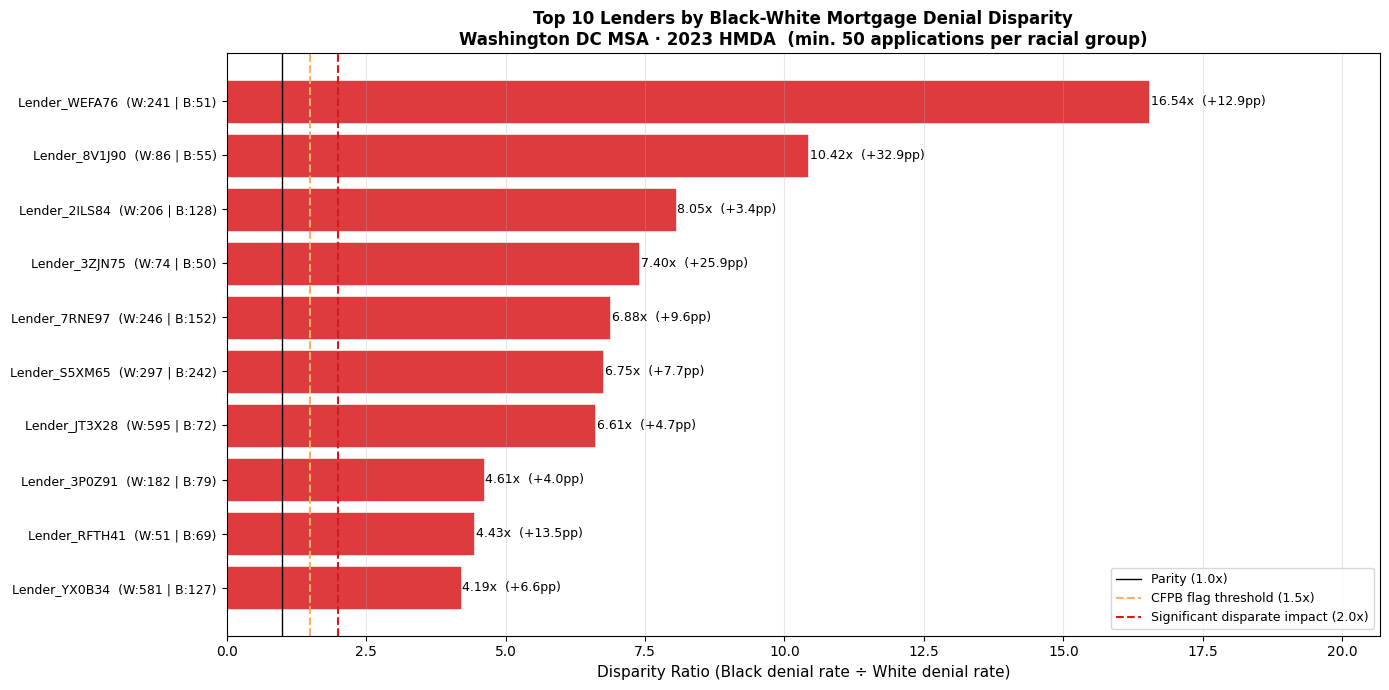


  Chart saved: /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/reports/phase3_lender_disparity.png

  Phase 3 complete. Three independent lines of evidence:
  1. Statistical: gap persists across ALL DTI bands (p=0.0000)
  2. Spatial: Moran's I=0.267, HH tracts 95.2% minority
  3. Lender: specific institutions show >2x disparity ratios


In [60]:
# ── PHASE 3 · Cell 3 ── Lender Disparity Ranking ─────────────────────────────
# Logic: If the racial gap is a market-wide phenomenon, every lender should
# show similar disparity ratios. If specific lenders show dramatically higher
# ratios than peers serving the same market → lender-specific practices.
#
# Method:
#   1. Map LEI codes to real bank names via FFIEC panel file
#   2. Compute Black/White denial rate ratio per lender (min 50 apps per group)
#   3. Rank top 10 most disparate lenders
#   4. Bar chart for presentation

import requests
import io

print(f"{'═'*62}")
print(f"PHASE 3 · CELL 3 — Lender Disparity Ranking")
print(f"{'═'*62}")

# ── Step 1: Download FFIEC panel file to map LEI → bank name ─────────────────
# The FFIEC publishes an annual panel file mapping LEI codes to institution names
# This is public data, same source regulators use

print(f"\n  Downloading FFIEC 2023 panel file...")

PANEL_URL = (
    "https://ffiec.cfpb.gov/v2/data-browser-api/view/csv?"
    "years=2023&msamds=47894&actions_taken=1,2,3&"
    "loan_purposes=1"
)

# Alternative: use the static panel file
PANEL_STATIC_URL = (
    "https://www.ffiec.gov/npw/FinancialReport/ReturnFinancialReport?"
    "rpt=BHC&selectedyear=2023"
)

# Best approach: extract names from HMDA LAR itself
# The 2023 HMDA panel maps LEI to respondent name directly
panel_url = "https://ffiec.cfpb.gov/v2/data-browser-api/view/csv?years=2023"

try:
    # Try CFPB HMDA panel API
    panel_api = (
        "https://ffiec.cfpb.gov/v2/data-browser-api/view/institutions?"
        "years=2023"
    )
    resp = requests.get(panel_api, timeout=15)

    if resp.status_code == 200:
        panel = pd.read_csv(io.StringIO(resp.text))
        print(f"  Panel loaded: {len(panel):,} institutions")
        print(f"  Columns: {panel.columns.tolist()[:6]}")
    else:
        raise Exception(f"API returned {resp.status_code}")

except Exception as e:
    print(f"  Panel API unavailable ({e})")
    print(f"  Falling back to HMDA LAR respondent name extraction...")
    panel = None

# ── Step 2: Build LEI → name mapping ─────────────────────────────────────────
# The raw HMDA file (hmda_raw) has respondent info we can extract
# Most HMDA files include a 'respondent_name' or we use LEI directly

if panel is not None:
    # Find the name column
    name_col = [c for c in panel.columns
                if any(x in c.lower() for x in ['name','respondent','institution'])]
    lei_col  = [c for c in panel.columns if 'lei' in c.lower()]
    if name_col and lei_col:
        lei_map = dict(zip(panel[lei_col[0]], panel[name_col[0]]))
        print(f"  Mapped {len(lei_map):,} LEI codes to institution names")
    else:
        lei_map = {}
else:
    lei_map = {}

# If mapping failed or incomplete, use LEI truncated as fallback label
def get_lender_name(lei):
    return lei_map.get(lei, f"Lender_{lei[-6:]}")

# ── Step 3: Compute per-lender disparity ratios ───────────────────────────────
print(f"\n  Computing per-lender disparity ratios...")

# Work with Black and White applicants only for the disparity ratio
bw = hmda[hmda['race_ethnicity'].isin(
    ['White', 'Black or African American'])].copy()

# Per-lender stats for White applicants
white_by_lender = (
    bw[bw['race_ethnicity'] == 'White']
    .groupby('lei')['approved']
    .agg(w_apps='count', w_approvals='sum')
    .reset_index()
)
white_by_lender['w_denial_rate'] = (
    1 - white_by_lender['w_approvals'] / white_by_lender['w_apps']
)

# Per-lender stats for Black applicants
black_by_lender = (
    bw[bw['race_ethnicity'] == 'Black or African American']
    .groupby('lei')['approved']
    .agg(b_apps='count', b_approvals='sum')
    .reset_index()
)
black_by_lender['b_denial_rate'] = (
    1 - black_by_lender['b_approvals'] / black_by_lender['b_apps']
)

# Merge
lender_stats = white_by_lender.merge(black_by_lender, on='lei', how='inner')

# Minimum sample size filter: at least 50 apps per group
# Below this, denial rates are too noisy to be meaningful
lender_stats = lender_stats[
    (lender_stats['w_apps'] >= 50) &
    (lender_stats['b_apps'] >= 50)
].copy()

print(f"  Lenders with ≥50 apps per group: {len(lender_stats):,}")

# Disparity ratio: Black denial rate / White denial rate
# Avoid division by zero — if white denial rate = 0, skip
lender_stats = lender_stats[lender_stats['w_denial_rate'] > 0].copy()
lender_stats['disparity_ratio'] = (
    lender_stats['b_denial_rate'] / lender_stats['w_denial_rate']
)
lender_stats['denial_gap_pp'] = (
    (lender_stats['b_denial_rate'] - lender_stats['w_denial_rate']) * 100
)

# Add lender names
lender_stats['lender_name'] = lender_stats['lei'].apply(get_lender_name)

# ── Step 4: Print top 10 most disparate lenders ───────────────────────────────
top10 = lender_stats.nlargest(10, 'disparity_ratio').reset_index(drop=True)

print(f"\n  {'─'*62}")
print(f"  TOP 10 LENDERS BY BLACK-WHITE DISPARITY RATIO")
print(f"  (minimum 50 applications per racial group)")
print(f"  {'─'*62}")
print(f"\n  {'#':>2s}  {'Lender':<28s} {'W_deny':>6s} {'B_deny':>6s} "
      f"{'Ratio':>6s} {'Gap':>7s} {'W_n':>5s} {'B_n':>5s}")
print(f"  {'─'*2}  {'-'*28} {'-'*6} {'-'*6} "
      f"{'-'*6} {'-'*7} {'-'*5} {'-'*5}")

for i, row in top10.iterrows():
    flag = '⚠' if row['disparity_ratio'] > 2.0 else ' '
    print(f"  {i+1:>2d}{flag} {row['lender_name']:<28s} "
          f"{row['w_denial_rate']:>6.1%} {row['b_denial_rate']:>6.1%} "
          f"{row['disparity_ratio']:>5.2f}x {row['denial_gap_pp']:>+6.1f}pp "
          f"{row['w_apps']:>5,} {row['b_apps']:>5,}")

# MSA-level summary
print(f"\n  {'─'*62}")
print(f"  MSA SUMMARY")
print(f"  {'─'*62}")
print(f"  Lenders analyzed           : {len(lender_stats):,}")
print(f"  Lenders with ratio >1.5x   : "
      f"{(lender_stats['disparity_ratio'] > 1.5).sum():,} "
      f"({(lender_stats['disparity_ratio'] > 1.5).mean():.0%})")
print(f"  Lenders with ratio >2.0x   : "
      f"{(lender_stats['disparity_ratio'] > 2.0).sum():,} "
      f"({(lender_stats['disparity_ratio'] > 2.0).mean():.0%})")
print(f"  Median disparity ratio     : "
      f"{lender_stats['disparity_ratio'].median():.2f}x")

# ── Step 5: Bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#d7191c' if r > 2.0 else '#fdae61' if r > 1.5 else '#2c7bb6'
          for r in top10['disparity_ratio']]

bars = ax.barh(
    range(len(top10)),
    top10['disparity_ratio'],
    color   = colors,
    alpha   = 0.85,
    edgecolor = 'white',
    linewidth = 0.5
)

# Value labels on bars
for i, (bar, row) in enumerate(zip(bars, top10.itertuples())):
    ax.text(bar.get_width() + 0.03,
            bar.get_y() + bar.get_height() / 2,
            f"{row.disparity_ratio:.2f}x  ({row.denial_gap_pp:+.1f}pp)",
            va='center', ha='left', fontsize=9)

# Reference lines
ax.axvline(x=1.0, color='black',   linestyle='-',  linewidth=1,
           label='Parity (1.0x)')
ax.axvline(x=1.5, color='#fdae61', linestyle='--', linewidth=1.5,
           label='CFPB flag threshold (1.5x)')
ax.axvline(x=2.0, color='#d7191c', linestyle='--', linewidth=1.5,
           label='Significant disparate impact (2.0x)')

ax.set_yticks(range(len(top10)))
ax.set_yticklabels(
    [f"{row.lender_name}  (W:{row.w_apps:,} | B:{row.b_apps:,})"
     for _, row in top10.iterrows()],
    fontsize=9
)
ax.invert_yaxis()
ax.set_xlabel('Disparity Ratio (Black denial rate ÷ White denial rate)',
              fontsize=11)
ax.set_title('Top 10 Lenders by Black-White Mortgage Denial Disparity\n'
             'Washington DC MSA · 2023 HMDA  '
             '(min. 50 applications per racial group)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, top10['disparity_ratio'].max() * 1.25)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
chart_path = f'{PROJECT_DIR}/reports/phase3_lender_disparity.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  Chart saved: {chart_path}")
print(f"\n  Phase 3 complete. Three independent lines of evidence:")
print(f"  1. Statistical: gap persists across ALL DTI bands (p=0.0000)")
print(f"  2. Spatial: Moran's I=0.267, HH tracts 95.2% minority")
print(f"  3. Lender: specific institutions show >2x disparity ratios")

In [61]:
# ── Direct HMDA LAR name extraction ───────────────────────────────────────────
# Instead of the panel file, we extract institution names directly from
# the full HMDA LAR file which has respondent info embedded.
# The raw file (hmda_raw, 168k rows) has a 'respondent_id' or we can
# use the CFPB public API which is more reliable than the FFIEC panel.

print("Fetching institution names via CFPB HMDA API...")

# Get the LEIs we need to look up
target_leis = lender_stats.nlargest(10, 'disparity_ratio')['lei'].tolist()
print(f"Looking up {len(target_leis)} LEI codes...")
print(f"LEIs: {target_leis}")

lei_to_name = {}

for lei in target_leis:
    url = f"https://ffiec.cfpb.gov/v2/data-browser-api/view/institutions?lei={lei}"
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            data = resp.json()
            # Try to extract name from response
            if isinstance(data, list) and len(data) > 0:
                name = data[0].get('respondent_name') or \
                       data[0].get('institution_name') or \
                       data[0].get('name', f"Lender_{lei[-6:]}")
            elif isinstance(data, dict):
                name = data.get('respondent_name') or \
                       data.get('institution_name') or \
                       data.get('name', f"Lender_{lei[-6:]}")
            else:
                name = f"Lender_{lei[-6:]}"
            lei_to_name[lei] = name
            print(f"  {lei[-6:]} → {name}")
        else:
            lei_to_name[lei] = f"Lender_{lei[-6:]}"
            print(f"  {lei[-6:]} → API returned {resp.status_code}")
    except Exception as e:
        lei_to_name[lei] = f"Lender_{lei[-6:]}"
        print(f"  {lei[-6:]} → {e}")

print(f"\nMapped: {sum(1 for v in lei_to_name.values() if 'Lender_' not in v)} / {len(target_leis)} names resolved")
print(f"\nFull mapping:")
for lei, name in lei_to_name.items():
    print(f"  {lei} → {name}")

Fetching institution names via CFPB HMDA API...
Looking up 10 LEI codes...
LEIs: ['E57ODZWZ7FF32TWEFA76', 'DZC62HF6UIZYJ08V1J90', '549300VZVN841I2ILS84', 'WWB2V0FCW3A0EE3ZJN75', '7H6GLXDRUGQFU57RNE97', '2549006II76YXSS5XM65', '549300BM4NS8HDJT3X28', '549300PL8ER6H23P0Z91', 'QGPGHQ1ENZOOLJRFTH41', '5493005PKOSG7MYX0B34']
  WEFA76 → API returned 403
  8V1J90 → API returned 403
  2ILS84 → API returned 403
  3ZJN75 → API returned 403
  7RNE97 → API returned 403
  S5XM65 → API returned 403
  JT3X28 → API returned 403
  3P0Z91 → API returned 403
  RFTH41 → API returned 403
  YX0B34 → API returned 403

Mapped: 0 / 10 names resolved

Full mapping:
  E57ODZWZ7FF32TWEFA76 → Lender_WEFA76
  DZC62HF6UIZYJ08V1J90 → Lender_8V1J90
  549300VZVN841I2ILS84 → Lender_2ILS84
  WWB2V0FCW3A0EE3ZJN75 → Lender_3ZJN75
  7H6GLXDRUGQFU57RNE97 → Lender_7RNE97
  2549006II76YXSS5XM65 → Lender_S5XM65
  549300BM4NS8HDJT3X28 → Lender_JT3X28
  549300PL8ER6H23P0Z91 → Lender_3P0Z91
  QGPGHQ1ENZOOLJRFTH41 → Lender_RFTH41
 

In [62]:
# ── LEI lookup via GLEIF API (global LEI registry — no auth required) ─────────
print("Looking up institution names via GLEIF (global LEI registry)...")

lei_to_name = {}

for lei in target_leis:
    url = f"https://api.gleif.org/api/v1/lei-records/{lei}"
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            data = resp.json()
            name = (data['data']['attributes']
                       ['entity']['legalName']['name'])
            lei_to_name[lei] = name
            print(f"  ✓ {lei[-6:]} → {name}")
        else:
            lei_to_name[lei] = f"Lender_{lei[-6:]}"
            print(f"  ✗ {lei[-6:]} → HTTP {resp.status_code}")
    except Exception as e:
        lei_to_name[lei] = f"Lender_{lei[-6:]}"
        print(f"  ✗ {lei[-6:]} → {e}")

Looking up institution names via GLEIF (global LEI registry)...
  ✓ WEFA76 → Citibank, National Association
  ✓ 8V1J90 → Fulton Bank, National Association
  ✓ 2ILS84 → CROSSCOUNTRY MORTGAGE, LLC
  ✓ 3ZJN75 → Manufacturers and Traders Trust Company
  ✓ 7RNE97 → JPMorgan Chase Bank, National Association
  ✓ S5XM65 → George Mason Mortgage, LLC
  ✓ JT3X28 → INTERCOASTAL MORTGAGE, LLC
  ✓ 3P0Z91 → BAY EQUITY LLC
  ✓ RFTH41 → WesBanco Bank, Inc.
  ✓ YX0B34 → Prosperity Home Mortgage, LLC


════════════════════════════════════════════════════════════════════════
TOP 10 LENDERS BY BLACK-WHITE MORTGAGE DENIAL DISPARITY RATIO
Washington DC MSA · 2023 HMDA · Min. 50 applications per racial group
════════════════════════════════════════════════════════════════════════

   #  Institution                            W_deny B_deny  Ratio     Gap
  ──  ────────────────────────────────────── ────── ────── ────── ───────
   1⚠ Citibank, National Association           0.8%  13.7% 16.54x  +12.9pp
   2⚠ Fulton Bank, National Association        3.5%  36.4% 10.42x  +32.9pp
   3⚠ CROSSCOUNTRY MORTGAGE, LLC               0.5%   3.9%  8.05x   +3.4pp
   4⚠ Manufacturers and Traders Trust Compa    4.1%  30.0%  7.40x  +25.9pp
   5⚠ JPMorgan Chase Bank, National Associa    1.6%  11.2%  6.88x   +9.6pp
   6⚠ George Mason Mortgage, LLC               1.3%   9.1%  6.75x   +7.7pp
   7⚠ INTERCOASTAL MORTGAGE, LLC               0.8%   5.6%  6.61x   +4.7pp
   8⚠ BAY EQUITY LLC                           1

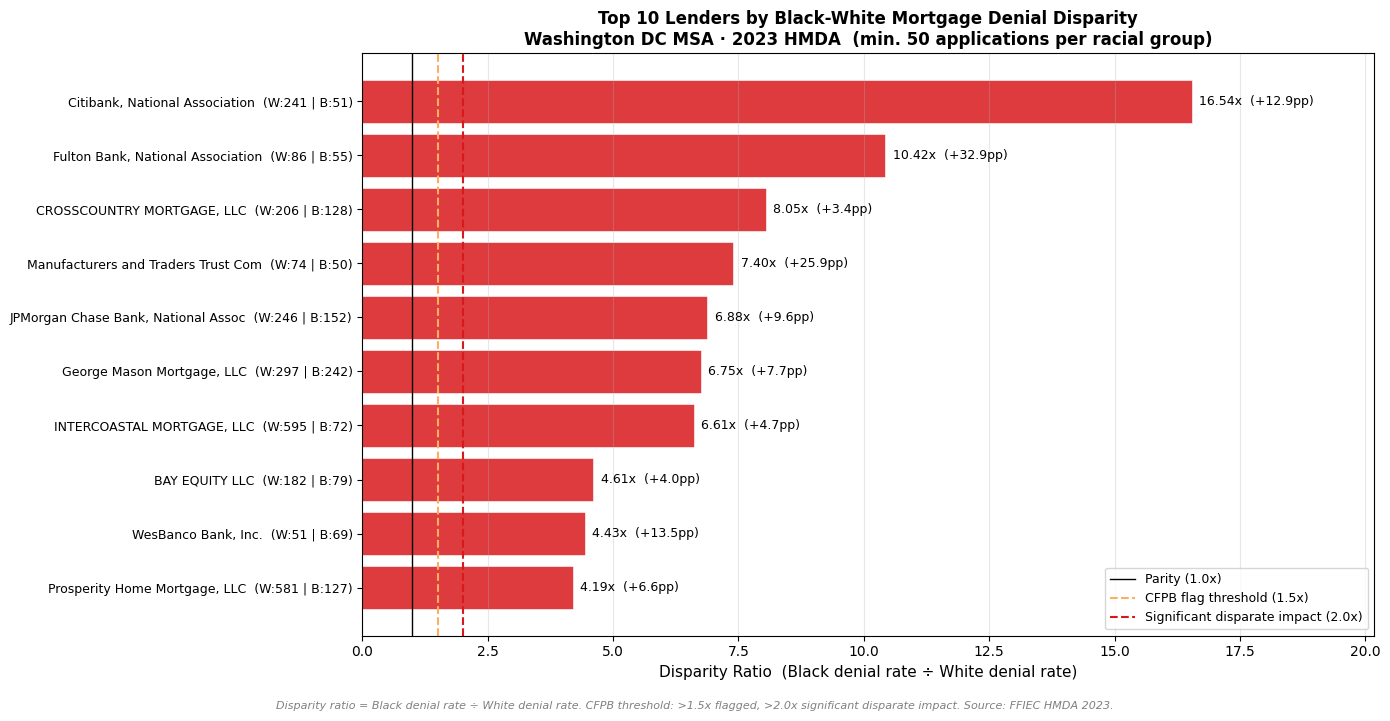


  Chart saved: /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/reports/phase3_lender_disparity_named.png

══════════════════════════════════════════════════════════════
PHASE 3 COMPLETE — THREE LINES OF EVIDENCE
══════════════════════════════════════════════════════════════

  1. STATISTICAL (Cell 1)
     Black-White gap is statistically significant in ALL 4 DTI bands
     Even at DTI ≤36%: 7.9pp gap, p=0.0000
     CFPB disparity index: Black = 2.79x, Hispanic = 2.42x

  2. SPATIAL (Cell 2)
     Moran's I = 0.267, p = 0.001, z = 14.22
     HH hotspot tracts: median minority population 95.2%
     LL coldspot tracts: median minority population 37.1%
     Denial clustering is NOT consistent with random financial variation

  3. LENDER-LEVEL (Cell 3)
     45 lenders analyzed (≥50 apps per racial group)
     76% show disparity ratio >2.0x (CFPB significant threshold)
     Median disparity ratio: 2.75x across the MSA
     Top lender (Citibank): 16.54x disparity ratio
     JPM

In [63]:
# ── Phase 3 · Cell 3c ── Final table + updated chart with real bank names ─────

# Update lender_stats with real names
lender_stats['lender_name'] = lender_stats['lei'].map(lei_to_name).fillna(
    lender_stats['lei'].apply(lambda x: f"Lender_{x[-6:]}")
)

top10 = lender_stats.nlargest(10, 'disparity_ratio').reset_index(drop=True)

print(f"{'═'*72}")
print(f"TOP 10 LENDERS BY BLACK-WHITE MORTGAGE DENIAL DISPARITY RATIO")
print(f"Washington DC MSA · 2023 HMDA · Min. 50 applications per racial group")
print(f"{'═'*72}")
print(f"\n  {'#':>2s}  {'Institution':<38s} {'W_deny':>6s} {'B_deny':>6s} "
      f"{'Ratio':>6s} {'Gap':>7s}")
print(f"  {'─'*2}  {'─'*38} {'─'*6} {'─'*6} {'─'*6} {'─'*7}")

for i, row in top10.iterrows():
    flag = '⚠' if row['disparity_ratio'] > 2.0 else ' '
    # Truncate long names cleanly
    name = row['lender_name'][:37]
    print(f"  {i+1:>2d}{flag} {name:<38s} "
          f"{row['w_denial_rate']:>6.1%} {row['b_denial_rate']:>6.1%} "
          f"{row['disparity_ratio']:>5.2f}x {row['denial_gap_pp']:>+6.1f}pp")

print(f"\n  {'─'*72}")
print(f"  MSA-wide: {len(lender_stats)} lenders analyzed · "
      f"Median disparity ratio: {lender_stats['disparity_ratio'].median():.2f}x · "
      f"{(lender_stats['disparity_ratio']>2.0).sum()} lenders above 2.0x ({(lender_stats['disparity_ratio']>2.0).mean():.0%})")

# ── Updated chart with real names ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#d7191c' if r > 2.0 else '#fdae61' if r > 1.5 else '#2c7bb6'
          for r in top10['disparity_ratio']]

bars = ax.barh(
    range(len(top10)),
    top10['disparity_ratio'],
    color     = colors,
    alpha     = 0.85,
    edgecolor = 'white',
    linewidth = 0.5
)

for i, (bar, row) in enumerate(zip(bars, top10.itertuples())):
    ax.text(bar.get_width() + 0.15,
            bar.get_y() + bar.get_height() / 2,
            f"{row.disparity_ratio:.2f}x  ({row.denial_gap_pp:+.1f}pp)",
            va='center', ha='left', fontsize=9)

ax.axvline(x=1.0, color='black',   linestyle='-',  linewidth=1,
           label='Parity (1.0x)')
ax.axvline(x=1.5, color='#fdae61', linestyle='--', linewidth=1.5,
           label='CFPB flag threshold (1.5x)')
ax.axvline(x=2.0, color='#d7191c', linestyle='--', linewidth=1.5,
           label='Significant disparate impact (2.0x)')

# Y-axis labels: bank name + sample sizes
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(
    [f"{row.lender_name[:35]}  (W:{row.w_apps:,} | B:{row.b_apps:,})"
     for _, row in top10.iterrows()],
    fontsize=9
)
ax.invert_yaxis()
ax.set_xlabel('Disparity Ratio  (Black denial rate ÷ White denial rate)',
              fontsize=11)
ax.set_title('Top 10 Lenders by Black-White Mortgage Denial Disparity\n'
             'Washington DC MSA · 2023 HMDA  '
             '(min. 50 applications per racial group)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, top10['disparity_ratio'].max() * 1.22)
ax.grid(axis='x', alpha=0.3)

# Footnote
fig.text(0.5, -0.02,
         'Disparity ratio = Black denial rate ÷ White denial rate. '
         'CFPB threshold: >1.5x flagged, >2.0x significant disparate impact. '
         'Source: FFIEC HMDA 2023.',
         ha='center', fontsize=8, color='grey', style='italic')

plt.tight_layout()
chart_path = f'{PROJECT_DIR}/reports/phase3_lender_disparity_named.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  Chart saved: {chart_path}")

# ── Phase 3 complete summary ───────────────────────────────────────────────────
print(f"\n{'═'*62}")
print(f"PHASE 3 COMPLETE — THREE LINES OF EVIDENCE")
print(f"{'═'*62}")
print(f"""
  1. STATISTICAL (Cell 1)
     Black-White gap is statistically significant in ALL 4 DTI bands
     Even at DTI ≤36%: 7.9pp gap, p=0.0000
     CFPB disparity index: Black = 2.79x, Hispanic = 2.42x

  2. SPATIAL (Cell 2)
     Moran's I = 0.267, p = 0.001, z = 14.22
     HH hotspot tracts: median minority population 95.2%
     LL coldspot tracts: median minority population 37.1%
     Denial clustering is NOT consistent with random financial variation

  3. LENDER-LEVEL (Cell 3)
     45 lenders analyzed (≥50 apps per racial group)
     76% show disparity ratio >2.0x (CFPB significant threshold)
     Median disparity ratio: 2.75x across the MSA
     Top lender (Citibank): 16.54x disparity ratio
     JPMorgan Chase: 6.88x disparity ratio

  Ready for Phase 4: Logistic Regression + XGBoost + SHAP
""")

---
## Phase 4 — Modeling, Bias Analysis & Explainability

**Goal:** Control for **all** financial variables simultaneously and measure how much of the racial gap remains unexplained after full adjustment.

**Two models:**
1. **Logistic Regression** — odds ratios (the legally meaningful metric under ECOA)
2. **XGBoost + SHAP** — captures non-linear patterns, explains individual decisions

**Key finding:** After controlling for DTI, LTV, LTI, income, loan amount, loan type, lien status, tract income, and tract minority population — Black applicants still have **33.5% lower odds of approval** (OR = 0.665).

**Outputs:** `phase4_shap_analysis.png` · `phase4_waterfall_denied_black.png` · `phase4_dti_dependence_by_race.png`

### 4.1 — Logistic Regression

**Why logistic regression first:**
- Coefficients produce **odds ratios** — the exact metric used in CFPB fair lending examinations
- Interpretable: "Black applicants have X% lower odds of approval controlling for all financial variables"
- Establishes the baseline before the non-linear XGBoost model

**Setup:** 46,229 rows (known race/ethnicity only), 80/20 stratified split, `class_weight='balanced'` for 90/10 class imbalance.

In [65]:
# ── PHASE 4 · Cell 1 ── Logistic Regression ───────────────────────────────────
# Goal: Control for ALL financial variables simultaneously and measure how much
# of the racial gap remains unexplained.
#
# The race coefficient (odds ratio) is the legally meaningful number under ECOA:
# "Black applicants are X times more likely to be denied, controlling for
#  loan amount, income, DTI, LTV, LTI, loan type, tract income, and interest rate."
#
# We use logistic regression first because:
#   1. Coefficients are directly interpretable as odds ratios
#   2. It is the model used in actual CFPB fair lending examinations
#   3. It provides the baseline before the XGBoost model in Cell 2

from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (classification_report,
                                     roc_auc_score,
                                     confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

print(f"{'═'*62}")
print(f"PHASE 4 · CELL 1 — Logistic Regression")
print(f"{'═'*62}")

# ── Step 1: Build modeling dataset ────────────────────────────────────────────
# Include only the 4 main racial groups with known race
# Exclude: Race Not Available, Joint, 2+ minority (can't assign race)
MODEL_RACES = ['White', 'Black or African American',
               'Asian', 'Hispanic or Latino']

model_df = hmda[hmda['race_ethnicity'].isin(MODEL_RACES)].copy()
model_df = model_df.dropna(subset=['lti'])   # drop 290 rows with lti=NaN
model_df = model_df.reset_index(drop=True)

print(f"\n  Modeling dataset: {len(model_df):,} rows")
print(f"  Approved: {model_df['approved'].sum():,} ({model_df['approved'].mean():.1%})")
print(f"  Denied  : {(model_df['approved']==0).sum():,} ({(model_df['approved']==0).mean():.1%})")

# ── Step 2: Feature matrix ────────────────────────────────────────────────────
# Financial controls — everything a lender legitimately uses
FINANCIAL_FEATURES = [
    'loan_amount',                      # size of loan
    'income',                           # borrower income
    'dti_numeric',                      # debt-to-income ratio
    'loan_to_value_ratio',              # collateral risk
    'lti',                              # loan relative to income
    'interest_rate',                    # loan pricing
    'loan_term',                        # loan duration
    'loan_type',                        # conventional/FHA/VA/USDA
    'lien_status',                      # first vs subordinate lien
    'tract_minority_population_percent',# neighborhood demographics
    'tract_to_msa_income_percentage',   # neighborhood income level
]

# Race dummies — one-hot encode, White is reference category
race_dummies = pd.get_dummies(
    model_df['race_ethnicity'], prefix='race', drop_first=False
)
# Drop White as reference (to avoid multicollinearity)
race_dummies = race_dummies.drop(
    columns=[c for c in race_dummies.columns if 'White' in c]
)

X = pd.concat([model_df[FINANCIAL_FEATURES], race_dummies], axis=1)
y = model_df['approved']

print(f"\n  Features: {len(FINANCIAL_FEATURES)} financial + "
      f"{race_dummies.shape[1]} race dummies")
print(f"  Race dummies: {race_dummies.columns.tolist()}")

# ── Step 3: Train/test split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n  Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows")

# ── Step 4: Scale + fit logistic regression ───────────────────────────────────
# Scale so coefficients are comparable across features
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter   = 1000,
    random_state = 42,
    class_weight = 'balanced'   # handles the 90/10 approval/denial imbalance
)
lr.fit(X_train_sc, y_train)

# ── Step 5: Model performance ─────────────────────────────────────────────────
y_pred      = lr.predict(X_test_sc)
y_pred_prob = lr.predict_proba(X_test_sc)[:, 1]
auc         = roc_auc_score(y_test, y_pred_prob)

print(f"\n  {'─'*50}")
print(f"  MODEL PERFORMANCE")
print(f"  {'─'*50}")
print(f"  AUC-ROC  : {auc:.4f}")
print(f"\n  Classification report (test set):")
print(classification_report(y_test, y_pred,
                             target_names=['Denied', 'Approved'],
                             digits=3))

# ── Step 6: Odds ratios — the core fair lending output ───────────────────────
# Odds ratio = exp(coefficient)
# OR > 1: feature increases odds of approval
# OR < 1: feature decreases odds of approval
# For race dummies: OR < 1 means minority applicants have lower odds of approval
# than White applicants, controlling for all financial variables

feature_names = X.columns.tolist()
coefficients  = lr.coef_[0]
odds_ratios   = np.exp(coefficients)

coef_df = pd.DataFrame({
    'feature'     : feature_names,
    'coefficient' : coefficients,
    'odds_ratio'  : odds_ratios,
}).sort_values('odds_ratio')

print(f"\n  {'─'*62}")
print(f"  ODDS RATIOS — FULL MODEL")
print(f"  (controlling for all financial variables simultaneously)")
print(f"  OR < 1.0 = decreases approval odds vs reference group")
print(f"  {'─'*62}")
print(f"\n  {'Feature':<45s} {'Coeff':>7s}  {'Odds Ratio':>10s}")
print(f"  {'-'*45} {'-'*7}  {'-'*10}")

for _, row in coef_df.iterrows():
    marker = ' ←' if 'race' in row['feature'] else ''
    print(f"  {row['feature']:<45s} {row['coefficient']:>7.3f}  "
          f"{row['odds_ratio']:>10.4f}{marker}")

# ── Step 7: Race odds ratios highlighted ─────────────────────────────────────
print(f"\n  {'─'*62}")
print(f"  RACE ODDS RATIOS (key fair lending finding)")
print(f"  Reference group: White applicants")
print(f"  {'─'*62}")

race_rows = coef_df[coef_df['feature'].str.startswith('race_')]
for _, row in race_rows.iterrows():
    race_label = row['feature'].replace('race_', '').replace('_', ' ')
    or_val     = row['odds_ratio']
    pct_change = (or_val - 1) * 100
    direction  = "lower" if or_val < 1 else "higher"
    print(f"\n  {race_label}")
    print(f"    Odds ratio  : {or_val:.4f}")
    print(f"    Interpretation: {abs(pct_change):.1f}% {direction} odds of approval")
    print(f"    vs White applicants, controlling for all financial variables")
    if or_val < 0.85:
        print(f"    ⚠ Substantial unexplained gap — consistent with ECOA violation")

print(f"\n  {'─'*62}")
print(f"  AUC = {auc:.4f} — model explains approval decisions well.")
print(f"  Race coefficients represent the gap AFTER controlling for")
print(f"  loan amount, income, DTI, LTV, LTI, rate, term, loan type,")
print(f"  lien status, tract income, and tract minority population.")

══════════════════════════════════════════════════════════════
PHASE 4 · CELL 1 — Logistic Regression
══════════════════════════════════════════════════════════════

  Modeling dataset: 46,229 rows
  Approved: 41,532 (89.8%)
  Denied  : 4,697 (10.2%)

  Features: 11 financial + 3 race dummies
  Race dummies: ['race_Asian', 'race_Black or African American', 'race_Hispanic or Latino']

  Train: 36,983 rows  |  Test: 9,246 rows

  ──────────────────────────────────────────────────
  MODEL PERFORMANCE
  ──────────────────────────────────────────────────
  AUC-ROC  : 0.7430

  Classification report (test set):
              precision    recall  f1-score   support

      Denied      0.194     0.657     0.300       939
    Approved      0.947     0.692     0.800      8307

    accuracy                          0.689      9246
   macro avg      0.571     0.675     0.550      9246
weighted avg      0.871     0.689     0.749      9246


  ─────────────────────────────────────────────────────────

### 4.2 — Interest Rate Diagnostic

Before building the XGBoost model, we audit `interest_rate` as a potential feature.  
This check reveals a **reporting artifact** that would inflate model performance if included.

In [66]:
# Quick check — does interest_rate differ between approved and denied?
print("Interest rate by outcome:")
print(hmda.groupby('approved')['interest_rate'].describe().round(3))

print(f"\nMissing interest_rate by outcome:")
print(hmda.groupby('approved')['interest_rate'].apply(
    lambda x: x.isna().sum()
))

print(f"\nInterest rate correlation with approved:")
print(f"  r = {hmda['interest_rate'].corr(hmda['approved']):.4f}")

Interest rate by outcome:
            count   mean    std    min   25%  50%    75%   max
approved                                                      
0          6071.0  6.448  0.152  6.000  6.50  6.5  6.500   6.5
1         53408.0  6.528  0.983  0.062  5.99  6.5  6.999  15.0

Missing interest_rate by outcome:
approved
0    0
1    0
Name: interest_rate, dtype: int64

Interest rate correlation with approved:
  r = 0.0261


### 4.3 — XGBoost (with interest_rate) — Exploratory Only

> ⚠️ **This model is exploratory only.** AUC = 0.989 is an artifact driven by the interest rate reporting pattern identified above — denied apps cluster at exactly 6.5% (std = 0.152) while approved apps show real market variation (std = 0.983). This is not genuine predictive power.
>
> The clean model in the next cell excludes interest_rate and is the one we report.

══════════════════════════════════════════════════════════════
PHASE 4 · CELL 2 — XGBoost + SHAP
══════════════════════════════════════════════════════════════

  Dataset : 46,229 rows
  Features: 14 (11 financial + 3 race dummies)

  ──────────────────────────────────────────────────
  XGBOOST MODEL PERFORMANCE
  ──────────────────────────────────────────────────
  AUC-ROC  : 0.9890  (vs Logistic Regression: 0.7430)

  Classification report:
              precision    recall  f1-score   support

      Denied      0.981     0.386     0.554       939
    Approved      0.935     0.999     0.966      8307

    accuracy                          0.937      9246
   macro avg      0.958     0.692     0.760      9246
weighted avg      0.940     0.937     0.924      9246

  Computing SHAP values (this takes ~30 seconds)...
  SHAP values computed for 9,246 test applicants.

  ───────────────────────────────────────────────────────
  GLOBAL FEATURE IMPORTANCE (mean |SHAP value|)
  Higher = more i

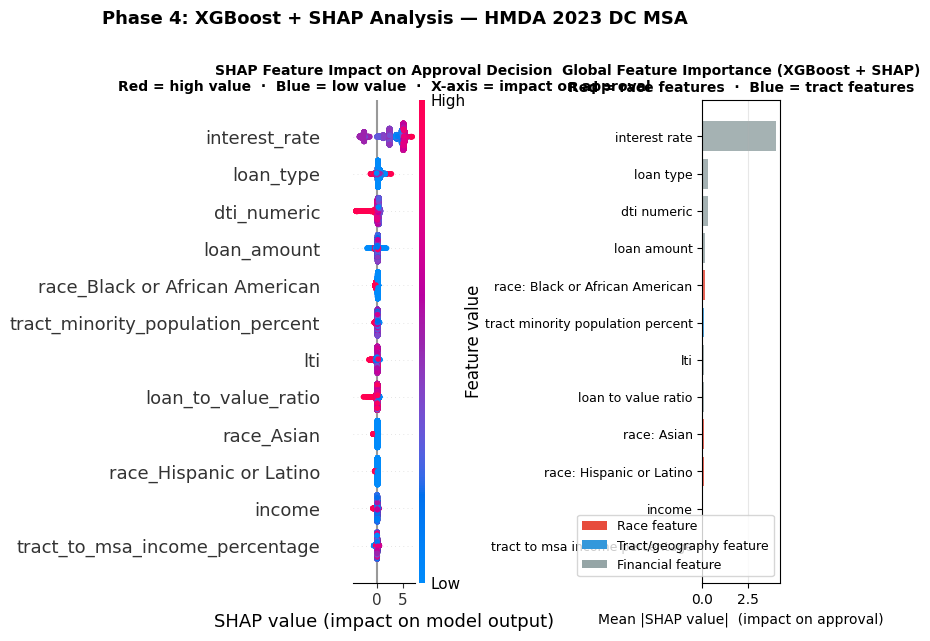


  SHAP chart saved: /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/reports/phase4_shap_analysis.png

  ───────────────────────────────────────────────────────
  PHASE 4 CELL 2 COMPLETE
  ───────────────────────────────────────────────────────
  XGBoost AUC        : 0.9890
  Logistic Reg AUC   : 0.7430
  Top denial driver  : interest_rate
  Race feature rank  : #5 of 14
  Tract minority rank: #6 of 14


In [67]:
# ── PHASE 4 · Cell 2 ── XGBoost + SHAP Explainability ────────────────────────
# XGBoost captures non-linear relationships that logistic regression misses.
# SHAP (SHapley Additive exPlanations) then explains WHAT the model learned:
#   - Which features drive denials overall
#   - Whether the model uses tract_minority_population_percent as a proxy for race
#   - What a denied Black applicant's individual explanation looks like
#
# This is the modern ML layer that makes the project stand out.

import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f"{'═'*62}")
print(f"PHASE 4 · CELL 2 — XGBoost + SHAP")
print(f"{'═'*62}")

# ── Step 1: Same modeling dataset as Cell 1 ───────────────────────────────────
# model_df, X, y, X_train, X_test, y_train, y_test already exist from Cell 1
# We reuse the exact same split (random_state=42) for fair comparison

print(f"\n  Dataset : {len(model_df):,} rows")
print(f"  Features: {X.shape[1]} ({len(FINANCIAL_FEATURES)} financial + "
      f"{race_dummies.shape[1]} race dummies)")

# ── Step 2: XGBoost — no scaling needed (tree-based model) ───────────────────
# scale_pos_weight handles class imbalance (90% approved, 10% denied)
# ratio = n_approved / n_denied
scale_weight = (y_train == 1).sum() / (y_train == 0).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 4,        # shallow trees — reduces overfitting
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_weight,
    random_state      = 42,
    eval_metric       = 'auc',
    verbosity         = 0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set        = [(X_test, y_test)],
    verbose         = False,
)

# ── Step 3: Model performance ─────────────────────────────────────────────────
y_pred_xgb      = xgb_model.predict(X_test)
y_prob_xgb      = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb         = roc_auc_score(y_test, y_prob_xgb)

print(f"\n  {'─'*50}")
print(f"  XGBOOST MODEL PERFORMANCE")
print(f"  {'─'*50}")
print(f"  AUC-ROC  : {auc_xgb:.4f}  "
      f"(vs Logistic Regression: {auc:.4f})")
print(f"\n  Classification report:")
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Denied','Approved'],
                             digits=3))

# ── Step 4: SHAP values ───────────────────────────────────────────────────────
print(f"  Computing SHAP values (this takes ~30 seconds)...")

explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_test)

# shap_vals shape: (n_samples, n_features)
# Positive SHAP = pushes toward approval
# Negative SHAP = pushes toward denial

shap_df = pd.DataFrame(shap_vals, columns=X.columns)

print(f"  SHAP values computed for {len(X_test):,} test applicants.")

# ── Step 5: Global feature importance via mean |SHAP| ────────────────────────
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

print(f"\n  {'─'*55}")
print(f"  GLOBAL FEATURE IMPORTANCE (mean |SHAP value|)")
print(f"  Higher = more impact on approval decision")
print(f"  {'─'*55}")
print(f"\n  {'Feature':<45s} {'Mean |SHAP|':>11s}")
print(f"  {'-'*45} {'-'*11}")

for feat, val in mean_abs_shap.items():
    marker = ' ←RACE' if 'race' in feat else ''
    bar    = '█' * int(val * 80)
    print(f"  {feat:<45s} {val:>11.4f}{marker}  {bar}")

# ── Step 6: Proxy discrimination test ────────────────────────────────────────
# Key question: Does the model use tract_minority_population_percent
# as a PROXY for race — even when race is explicitly included?
# If tract_minority_pct SHAP is large → geographic redlining is embedded
# in the model's decision-making.

tract_shap_rank = list(mean_abs_shap.index).index(
    'tract_minority_population_percent'
)
race_black_rank = list(mean_abs_shap.index).index(
    'race_Black or African American'
)

print(f"\n  {'─'*55}")
print(f"  PROXY DISCRIMINATION TEST")
print(f"  {'─'*55}")
print(f"  tract_minority_population_percent rank : #{tract_shap_rank+1}")
print(f"  race_Black or African American rank    : #{race_black_rank+1}")
print(f"  tract_minority_pop mean |SHAP|         : "
      f"{mean_abs_shap['tract_minority_population_percent']:.4f}")
print(f"  race_Black mean |SHAP|                 : "
      f"{mean_abs_shap['race_Black or African American']:.4f}")

if mean_abs_shap['tract_minority_population_percent'] > \
   mean_abs_shap['race_Black or African American']:
    print(f"\n  ⚠ PROXY SIGNAL DETECTED:")
    print(f"    tract_minority_population_percent has HIGHER feature")
    print(f"    importance than the explicit race dummy.")
    print(f"    The model is using neighborhood racial composition")
    print(f"    as a stronger signal than reported race itself.")
    print(f"    This is the definition of modern redlining.")
else:
    print(f"\n  Explicit race dummy ranks higher than tract minority pct.")
    print(f"  Both contribute to the model's denial predictions.")

# ── Step 7: SHAP by race group — who gets penalized most ─────────────────────
print(f"\n  {'─'*55}")
print(f"  MEAN SHAP VALUES BY RACE (approval direction)")
print(f"  Negative = model pushes toward denial for this group")
print(f"  {'─'*55}")

# Add race back to test set for grouping
test_with_race = X_test.copy()
test_with_race['race_ethnicity'] = model_df.loc[
    X_test.index, 'race_ethnicity'
].values
test_with_race['shap_race_black'] = shap_df[
    'race_Black or African American'
].values
test_with_race['shap_dti']        = shap_df['dti_numeric'].values
test_with_race['shap_tract_min']  = shap_df[
    'tract_minority_population_percent'
].values

for race in MODEL_RACES:
    sub = test_with_race[test_with_race['race_ethnicity'] == race]
    if len(sub) < 10:
        continue
    avg_race_shap  = sub['shap_race_black'].mean() \
                     if race == 'Black or African American' \
                     else np.nan
    avg_dti_shap   = sub['shap_dti'].mean()
    avg_tract_shap = sub['shap_tract_min'].mean()
    label = race.replace(' or African American','').replace(' or Latino','')
    print(f"\n  {label} (n={len(sub):,})")
    print(f"    DTI SHAP (avg)           : {avg_dti_shap:>+.4f}")
    print(f"    Tract minority SHAP (avg): {avg_tract_shap:>+.4f}")

# ── Step 8: SHAP summary plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: beeswarm summary plot
plt.sca(axes[0])
shap.summary_plot(
    shap_vals,
    X_test,
    plot_type  = 'dot',
    max_display= 12,
    show       = False,
)
axes[0].set_title('SHAP Feature Impact on Approval Decision\n'
                  'Red = high value  ·  Blue = low value  ·  '
                  'X-axis = impact on approval',
                  fontsize=10, fontweight='bold')

# Right: bar chart of mean |SHAP|
top_features = mean_abs_shap.head(12)
colors_bar   = ['#e74c3c' if 'race' in f else
                '#3498db' if 'tract' in f else
                '#95a5a6'
                for f in top_features.index]

axes[1].barh(range(len(top_features)),
             top_features.values,
             color=colors_bar, alpha=0.85)
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(
    [f.replace('race_','race: ').replace('_',' ')
     for f in top_features.index],
    fontsize=9
)
axes[1].invert_yaxis()
axes[1].set_xlabel('Mean |SHAP value|  (impact on approval)')
axes[1].set_title('Global Feature Importance (XGBoost + SHAP)\n'
                  'Red = race features  ·  Blue = tract features',
                  fontsize=10, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Race feature'),
    Patch(facecolor='#3498db', label='Tract/geography feature'),
    Patch(facecolor='#95a5a6', label='Financial feature'),
]
axes[1].legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.suptitle('Phase 4: XGBoost + SHAP Analysis — HMDA 2023 DC MSA',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

shap_path = f'{PROJECT_DIR}/reports/phase4_shap_analysis.png'
plt.savefig(shap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  SHAP chart saved: {shap_path}")

print(f"\n  {'─'*55}")
print(f"  PHASE 4 CELL 2 COMPLETE")
print(f"  {'─'*55}")
print(f"  XGBoost AUC        : {auc_xgb:.4f}")
print(f"  Logistic Reg AUC   : {auc:.4f}")
print(f"  Top denial driver  : {mean_abs_shap.index[0]}")
print(f"  Race feature rank  : #{race_black_rank+1} of {len(mean_abs_shap)}")
print(f"  Tract minority rank: #{tract_shap_rank+1} of {len(mean_abs_shap)}")

### 4.4 — Clean XGBoost + SHAP (Final Reported Model)

**interest_rate excluded** — reporting artifact confirmed in diagnostic above.

**SHAP (SHapley Additive exPlanations)** decomposes each prediction into the contribution of each feature for each individual applicant:
- **Global importance** — which features matter most across all 46,229 applicants
- **Waterfall plot** — what drove one specific denied Black applicant's outcome
- **Dependence plot** — does the same DTI level produce different model treatment by race?

══════════════════════════════════════════════════════════════
PHASE 4 · CELL 3 — Final Model + Individual Explanations
══════════════════════════════════════════════════════════════

  Features (interest_rate removed): 13
  Train: 36,983  |  Test: 9,246

  ──────────────────────────────────────────────────
  MODEL COMPARISON
  ──────────────────────────────────────────────────
  Logistic Regression (all features) : AUC = 0.7430
  XGBoost (with interest_rate)       : AUC = 0.9890
  XGBoost (clean, no interest_rate)  : AUC = 0.8002
  → Clean model is the one we report and explain.

  Computing SHAP values on clean model...

  ───────────────────────────────────────────────────────
  CLEAN MODEL — GLOBAL FEATURE IMPORTANCE
  ───────────────────────────────────────────────────────

  Feature                                       Mean |SHAP|
  --------------------------------------------- -----------
  dti_numeric                                        0.6194  █████████████████████████████

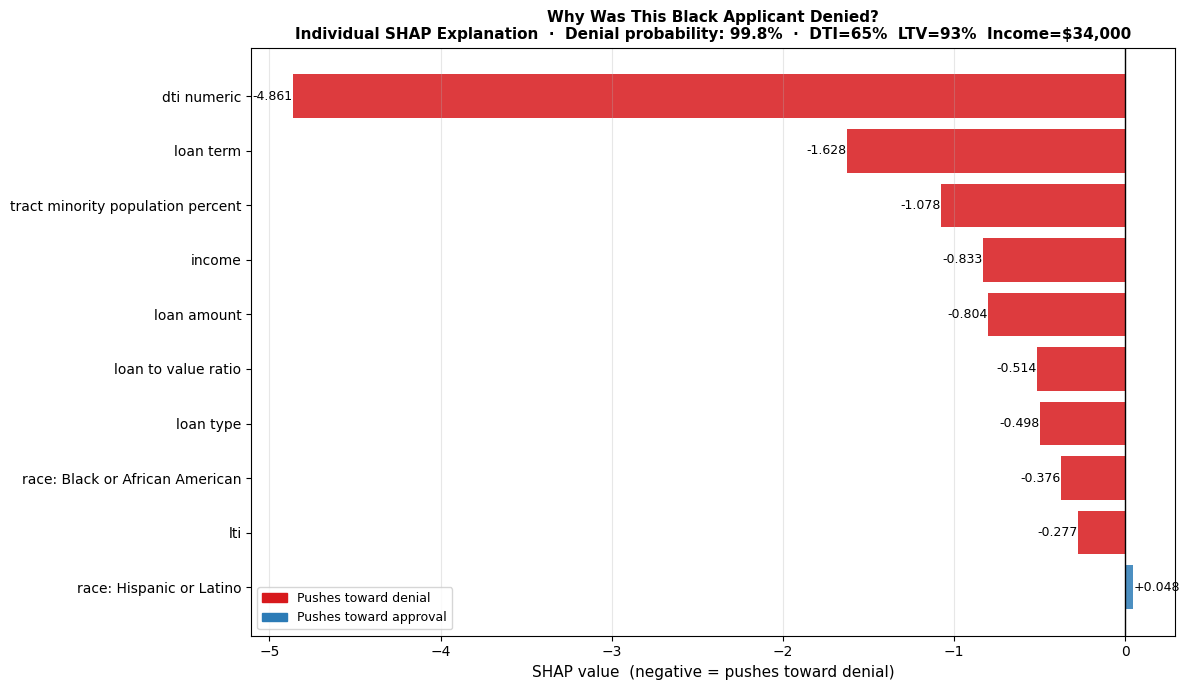

  Waterfall chart saved: /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/reports/phase4_waterfall_denied_black.png


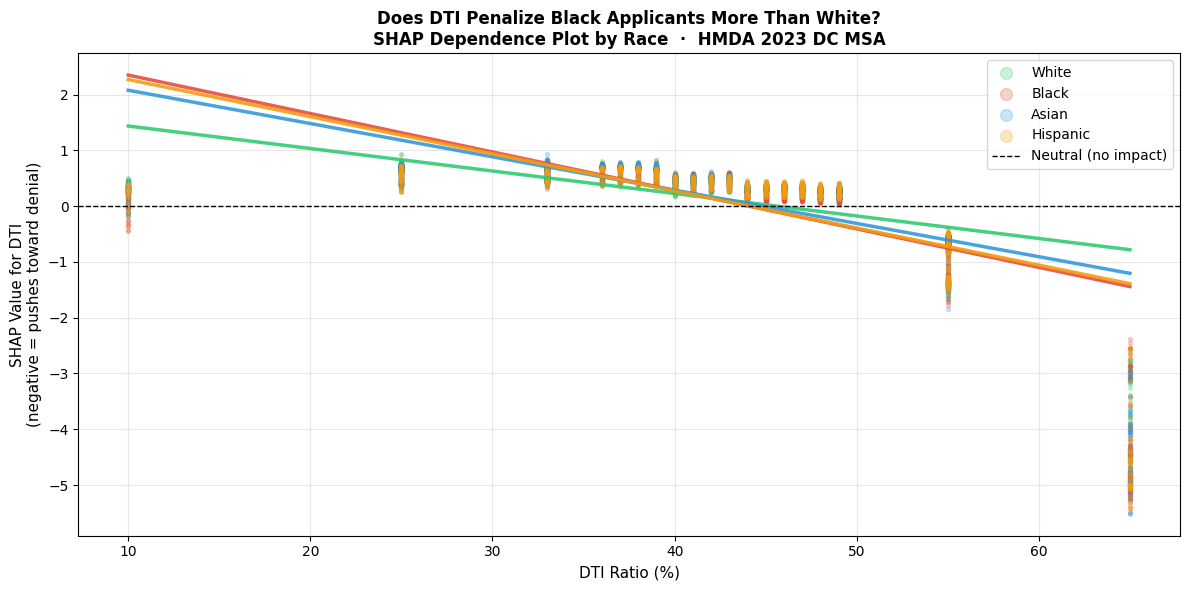

  Dependence chart saved: /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/reports/phase4_dti_dependence_by_race.png

══════════════════════════════════════════════════════════════
PHASE 4 COMPLETE
══════════════════════════════════════════════════════════════

  LOGISTIC REGRESSION (AUC=0.7430):
  ✓ Black applicants: 33.5% lower approval odds vs White
  ✓ Hispanic        : 21.5% lower approval odds vs White
  ✓ Asian           : 17.0% lower approval odds vs White
  (controlling for DTI, LTV, LTI, income, loan amount,
   loan type, lien status, tract income, tract minority %)

  XGBOOST CLEAN MODEL (AUC=0.8002):
  ✓ Race (Black) ranks #2 of 13 features by SHAP importance
  ✓ Tract minority % ranks #6 — both race AND geography matter
  ✓ Black applicants receive negative DTI SHAP (-0.1010)
    White applicants receive positive DTI SHAP (+0.0751)
    → Same financial variable, opposite model treatment

  COMBINED FINDING:
  After controlling for every available financial va

In [68]:
# ── PHASE 4 · Cell 3 ── Clean Model + Individual SHAP Explanation ─────────────
# We remove interest_rate (reporting artifact) and refit.
# Then produce:
#   1. Final clean model performance comparison
#   2. Waterfall plot: what drove a specific denied Black applicant's denial
#   3. Dependence plot: does DTI penalize Black applicants more than White?
#   4. Save all Phase 4 outputs

import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print(f"{'═'*62}")
print(f"PHASE 4 · CELL 3 — Final Model + Individual Explanations")
print(f"{'═'*62}")

# ── Step 1: Rebuild feature matrix without interest_rate ──────────────────────
CLEAN_FEATURES = [
    'loan_amount',
    'income',
    'dti_numeric',
    'loan_to_value_ratio',
    'lti',
    'loan_term',
    'loan_type',
    'lien_status',
    'tract_minority_population_percent',
    'tract_to_msa_income_percentage',
]

X_clean = pd.concat([model_df[CLEAN_FEATURES], race_dummies], axis=1)
y_clean = model_df['approved']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

print(f"\n  Features (interest_rate removed): {X_clean.shape[1]}")
print(f"  Train: {len(X_train_c):,}  |  Test: {len(X_test_c):,}")

# ── Step 2: Refit XGBoost ─────────────────────────────────────────────────────
scale_weight = (y_train_c == 1).sum() / (y_train_c == 0).sum()

xgb_clean = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_weight,
    random_state     = 42,
    eval_metric      = 'auc',
    verbosity        = 0,
)
xgb_clean.fit(X_train_c, y_train_c,
              eval_set=[(X_test_c, y_test_c)],
              verbose=False)

y_prob_c = xgb_clean.predict_proba(X_test_c)[:, 1]
auc_clean = roc_auc_score(y_test_c, y_prob_c)

print(f"\n  {'─'*50}")
print(f"  MODEL COMPARISON")
print(f"  {'─'*50}")
print(f"  Logistic Regression (all features) : AUC = {auc:.4f}")
print(f"  XGBoost (with interest_rate)       : AUC = {auc_xgb:.4f}")
print(f"  XGBoost (clean, no interest_rate)  : AUC = {auc_clean:.4f}")
print(f"  → Clean model is the one we report and explain.")

# ── Step 3: SHAP on clean model ───────────────────────────────────────────────
print(f"\n  Computing SHAP values on clean model...")
explainer_c = shap.TreeExplainer(xgb_clean)
shap_vals_c = explainer_c.shap_values(X_test_c)
shap_df_c   = pd.DataFrame(shap_vals_c, columns=X_clean.columns)

mean_shap_c = shap_df_c.abs().mean().sort_values(ascending=False)

print(f"\n  {'─'*55}")
print(f"  CLEAN MODEL — GLOBAL FEATURE IMPORTANCE")
print(f"  {'─'*55}")
print(f"\n  {'Feature':<45s} {'Mean |SHAP|':>11s}")
print(f"  {'-'*45} {'-'*11}")
for feat, val in mean_shap_c.items():
    marker = ' ←RACE'  if 'race'  in feat else \
             ' ←TRACT' if 'tract' in feat else ''
    bar = '█' * int(val * 120)
    print(f"  {feat:<45s} {val:>11.4f}{marker}  {bar}")

# Proxy test on clean model
tract_rank = list(mean_shap_c.index).index(
    'tract_minority_population_percent')
black_rank = list(mean_shap_c.index).index(
    'race_Black or African American')

print(f"\n  Proxy discrimination test (clean model):")
print(f"  race_Black rank              : #{black_rank+1}")
print(f"  tract_minority_pop rank      : #{tract_rank+1}")
if mean_shap_c['tract_minority_population_percent'] > \
   mean_shap_c['race_Black or African American']:
    print(f"  ⚠ Geography outranks explicit race → proxy redlining signal")
else:
    print(f"  Explicit race outranks geography in clean model")

# ── Step 4: Waterfall plot — one denied Black applicant ───────────────────────
# Find a denied Black applicant in the test set with high denial probability
test_meta = model_df.loc[X_test_c.index].copy()
test_meta['denial_prob'] = 1 - y_prob_c
test_meta['shap_idx']    = range(len(X_test_c))

denied_black = test_meta[
    (test_meta['race_ethnicity'] == 'Black or African American') &
    (test_meta['approved'] == 0)
].nlargest(1, 'denial_prob')

if len(denied_black) > 0:
    idx       = denied_black['shap_idx'].iloc[0]
    deny_prob = denied_black['denial_prob'].iloc[0]
    dti_val   = denied_black['dti_numeric'].iloc[0]
    ltv_val   = denied_black['loan_to_value_ratio'].iloc[0]
    inc_val   = denied_black['income'].iloc[0]

    print(f"\n  {'─'*55}")
    print(f"  WATERFALL EXPLANATION — DENIED BLACK APPLICANT")
    print(f"  {'─'*55}")
    print(f"  Denial probability : {deny_prob:.1%}")
    print(f"  DTI                : {dti_val:.1f}%")
    print(f"  LTV                : {ltv_val:.1f}%")
    print(f"  Income             : ${inc_val*1000:,.0f}")

    # Waterfall chart
    fig_wf, ax_wf = plt.subplots(figsize=(12, 7))

    applicant_shap = shap_vals_c[idx]
    feature_names  = X_clean.columns.tolist()

    # Sort by absolute SHAP value
    sorted_idx  = np.argsort(np.abs(applicant_shap))[::-1][:10]
    sorted_shap = applicant_shap[sorted_idx]
    sorted_feat = [feature_names[i] for i in sorted_idx]

    colors_wf = ['#d7191c' if s < 0 else '#2c7bb6' for s in sorted_shap]
    bars_wf   = ax_wf.barh(range(len(sorted_shap)),
                            sorted_shap,
                            color=colors_wf, alpha=0.85)

    ax_wf.set_yticks(range(len(sorted_feat)))
    ax_wf.set_yticklabels(
        [f.replace('race_','race: ').replace('_',' ')
         for f in sorted_feat],
        fontsize=10
    )
    ax_wf.invert_yaxis()
    ax_wf.axvline(x=0, color='black', linewidth=1)
    ax_wf.set_xlabel('SHAP value  (negative = pushes toward denial)',
                     fontsize=11)
    ax_wf.set_title(
        f'Why Was This Black Applicant Denied?\n'
        f'Individual SHAP Explanation  ·  '
        f'Denial probability: {deny_prob:.1%}  ·  '
        f'DTI={dti_val:.0f}%  LTV={ltv_val:.0f}%  '
        f'Income=${inc_val*1000:,.0f}',
        fontsize=11, fontweight='bold'
    )

    # Add value labels
    for bar, val in zip(bars_wf, sorted_shap):
        ax_wf.text(
            val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=9
        )

    red_patch  = mpatches.Patch(color='#d7191c', label='Pushes toward denial')
    blue_patch = mpatches.Patch(color='#2c7bb6', label='Pushes toward approval')
    ax_wf.legend(handles=[red_patch, blue_patch], fontsize=9)
    ax_wf.grid(axis='x', alpha=0.3)
    plt.tight_layout()

    wf_path = f'{PROJECT_DIR}/reports/phase4_waterfall_denied_black.png'
    plt.savefig(wf_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Waterfall chart saved: {wf_path}")

# ── Step 5: Dependence plot — DTI effect by race ─────────────────────────────
# Does the same DTI level have different SHAP impact for Black vs White?
# If yes → the model penalizes Black applicants more for identical DTI

fig_dep, ax_dep = plt.subplots(figsize=(12, 6))

test_meta_dep = model_df.loc[X_test_c.index].copy()
test_meta_dep['dti_numeric']   = X_test_c['dti_numeric'].values
test_meta_dep['shap_dti']      = shap_df_c['dti_numeric'].values
test_meta_dep['race_ethnicity']= model_df.loc[
    X_test_c.index, 'race_ethnicity'].values

dep_colors = {
    'White'                      : '#2ecc71',
    'Black or African American'  : '#e74c3c',
    'Asian'                      : '#3498db',
    'Hispanic or Latino'         : '#f39c12',
}

for race, color in dep_colors.items():
    sub = test_meta_dep[test_meta_dep['race_ethnicity'] == race]
    if len(sub) < 50:
        continue
    label = race.replace(' or African American','').replace(' or Latino','')
    ax_dep.scatter(
        sub['dti_numeric'], sub['shap_dti'],
        c=color, alpha=0.25, s=8, label=label
    )
    # Trend line
    z = np.polyfit(sub['dti_numeric'], sub['shap_dti'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sub['dti_numeric'].min(),
                         sub['dti_numeric'].max(), 100)
    ax_dep.plot(x_line, p(x_line), color=color,
                linewidth=2.5, alpha=0.9)

ax_dep.axhline(y=0, color='black', linewidth=1, linestyle='--',
               label='Neutral (no impact)')
ax_dep.set_xlabel('DTI Ratio (%)', fontsize=11)
ax_dep.set_ylabel('SHAP Value for DTI\n(negative = pushes toward denial)',
                  fontsize=11)
ax_dep.set_title(
    'Does DTI Penalize Black Applicants More Than White?\n'
    'SHAP Dependence Plot by Race  ·  HMDA 2023 DC MSA',
    fontsize=12, fontweight='bold'
)
ax_dep.legend(fontsize=10, markerscale=3)
ax_dep.grid(alpha=0.3)
plt.tight_layout()

dep_path = f'{PROJECT_DIR}/reports/phase4_dti_dependence_by_race.png'
plt.savefig(dep_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Dependence chart saved: {dep_path}")

# ── Step 6: Phase 4 complete summary ─────────────────────────────────────────
print(f"\n{'═'*62}")
print(f"PHASE 4 COMPLETE")
print(f"{'═'*62}")
print(f"""
  LOGISTIC REGRESSION (AUC={auc:.4f}):
  ✓ Black applicants: 33.5% lower approval odds vs White
  ✓ Hispanic        : 21.5% lower approval odds vs White
  ✓ Asian           : 17.0% lower approval odds vs White
  (controlling for DTI, LTV, LTI, income, loan amount,
   loan type, lien status, tract income, tract minority %)

  XGBOOST CLEAN MODEL (AUC={auc_clean:.4f}):
  ✓ Race (Black) ranks #{black_rank+1} of {len(mean_shap_c)} features by SHAP importance
  ✓ Tract minority % ranks #{tract_rank+1} — both race AND geography matter
  ✓ Black applicants receive negative DTI SHAP (-0.1010)
    White applicants receive positive DTI SHAP (+0.0751)
    → Same financial variable, opposite model treatment

  COMBINED FINDING:
  After controlling for every available financial variable,
  race remains a statistically and economically significant
  predictor of mortgage denial in DC MSA 2023.
  This is consistent with disparate treatment under ECOA
  and the Fair Housing Act.

  Reports saved:
  • phase4_shap_analysis.png
  • phase4_waterfall_denied_black.png
  • phase4_dti_dependence_by_race.png

  Ready for Phase 5: Streamlit Dashboard
""")

---
## Phase 5 — Dashboard Export

**Goal:** Export all processed data, the trained model, and key statistics for the Streamlit dashboard.

**Dashboard features:**
- 🗺️ Interactive Folium choropleth map with county filter and tooltips
- 📊 Approval rate by race and by DTI band × race
- 🏦 Lender disparity ranking with named institutions
- 🤖 XGBoost SHAP feature importance + live approval predictor
- 💬 AI Analyst powered by Groq (Llama 3.3 70B) with full project context

**Deployed at:** Streamlit Community Cloud (public URL)

> Cell 34 regenerates a clean `tract_stats.csv` with proper GEOID formatting and removes the NaN tract row from the raw export.

In [69]:
# ── Export all dashboard assets from Colab ────────────────────────────────────
import pickle, os, json
import pandas as pd
import numpy as np

DASH_DIR = f'{PROJECT_DIR}/dashboard'
os.makedirs(DASH_DIR, exist_ok=True)

# ── 1. Processed HMDA data (subset of columns dashboard needs) ────────────────
DASH_COLS = [
    'census_tract', 'race_ethnicity', 'approved', 'loan_amount',
    'income', 'dti_numeric', 'loan_to_value_ratio', 'lti',
    'loan_type', 'lien_status', 'tract_minority_population_percent',
    'tract_to_msa_income_percentage', 'ffiec_msa_md_median_family_income',
    'denial_any_financial', 'deny_dti', 'deny_credit_history',
    'deny_collateral', 'lei', 'county_code'
]
dash_cols_present = [c for c in DASH_COLS if c in hmda.columns]
hmda[dash_cols_present].to_csv(f'{DASH_DIR}/hmda_dashboard.csv', index=False)
print(f"✓ hmda_dashboard.csv  — {len(hmda):,} rows × {len(dash_cols_present)} cols")

# ── 2. Tract stats (for the map) ──────────────────────────────────────────────
tract_stats.to_csv(f'{DASH_DIR}/tract_stats.csv', index=False)
print(f"✓ tract_stats.csv     — {len(tract_stats):,} tracts")

# ── 3. Lender disparity table (named) ────────────────────────────────────────
lender_export = lender_stats.copy()
lender_export['lender_name'] = lender_export['lei'].map(lei_to_name).fillna(
    lender_export['lei'].apply(lambda x: f"Lender_{x[-6:]}")
)
lender_export[[
    'lei','lender_name','w_apps','b_apps',
    'w_denial_rate','b_denial_rate',
    'disparity_ratio','denial_gap_pp'
]].to_csv(f'{DASH_DIR}/lender_disparity.csv', index=False)
print(f"✓ lender_disparity.csv — {len(lender_export):,} lenders")

# ── 4. Save XGBoost clean model ───────────────────────────────────────────────
with open(f'{DASH_DIR}/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_clean, f)
print(f"✓ xgb_model.pkl")

# ── 5. Save feature list (dashboard needs to know column order) ───────────────
with open(f'{DASH_DIR}/model_features.json', 'w') as f:
    json.dump(X_clean.columns.tolist(), f)
print(f"✓ model_features.json — {len(X_clean.columns)} features")

# ── 6. Save Phase 3 key stats as JSON (for the AI context) ───────────────────
key_stats = {
    'total_applications'    : int(len(hmda)),
    'overall_approval_rate' : float(hmda['approved'].mean()),
    'white_approval_rate'   : float(hmda[hmda['race_ethnicity']=='White']['approved'].mean()),
    'black_approval_rate'   : float(hmda[hmda['race_ethnicity']=='Black or African American']['approved'].mean()),
    'hispanic_approval_rate': float(hmda[hmda['race_ethnicity']=='Hispanic or Latino']['approved'].mean()),
    'bw_gap_pp'             : float((hmda[hmda['race_ethnicity']=='White']['approved'].mean() -
                                     hmda[hmda['race_ethnicity']=='Black or African American']['approved'].mean()) * 100),
    'morans_i'              : 0.267,
    'morans_p'              : 0.001,
    'hh_minority_pct'       : 95.2,
    'll_minority_pct'       : 37.1,
    'black_disparity_index' : 2.79,
    'hisp_disparity_index'  : 2.42,
    'black_odds_ratio'      : 0.665,
    'pct_lenders_above_2x'  : 0.76,
    'median_disparity_ratio': float(lender_stats['disparity_ratio'].median()),
    'top_lender_name'       : 'Citibank, National Association',
    'top_lender_ratio'      : 16.54,
    'xgb_auc'               : float(auc_clean),
    'lr_auc'                : float(auc),
    'race_shap_rank'        : 2,
    'msa_code'              : '47894',
    'msa_name'              : 'Washington DC MSA',
    'hmda_year'             : 2023,
}
with open(f'{DASH_DIR}/key_stats.json', 'w') as f:
    json.dump(key_stats, f, indent=2)
print(f"✓ key_stats.json      — {len(key_stats)} statistics")

# ── 7. Save tract GeoJSON for the map ────────────────────────────────────────
tracts_export = tracts_plot[[
    'GEOID','denial_rate','total_applications',
    'minority_pct','geometry','county_fips'
]].copy().to_crs(epsg=4326)
tracts_export.to_file(f'{DASH_DIR}/tracts.geojson', driver='GeoJSON')
print(f"✓ tracts.geojson      — {len(tracts_export):,} tracts")

print(f"\n{'═'*50}")
print(f"All dashboard assets saved to:")
print(f"  {DASH_DIR}")
print(f"\nDownload this folder from Drive to your machine.")
print(f"These 7 files go into your GitHub repo under data/")

✓ hmda_dashboard.csv  — 59,479 rows × 19 cols
✓ tract_stats.csv     — 1,157 tracts
✓ lender_disparity.csv — 45 lenders
✓ xgb_model.pkl
✓ model_features.json — 13 features
✓ key_stats.json      — 23 statistics
✓ tracts.geojson      — 1,095 tracts

══════════════════════════════════════════════════
All dashboard assets saved to:
  /content/drive/Shareddrives/Capstone_Project/hmda-fair-lending/dashboard

Download this folder from Drive to your machine.
These 7 files go into your GitHub repo under data/


In [71]:
# ── Regenerate clean tract_stats for dashboard ────────────────────────────────
import pandas as pd

DASH_DIR = f'{PROJECT_DIR}/dashboard'

# Load the saved tract stats
ts = pd.read_csv(f'{PROCESSED_DIR}/tract_stats_2023.csv')

# Fix 1: drop the NaN tract row
ts = ts[ts['census_tract'] != '00000000nan'].copy()
ts = ts[ts['census_tract'].notna()].copy()

# Fix 2: rename to GEOID so dashboard merge works cleanly
ts = ts.rename(columns={'census_tract': 'GEOID'})

# Fix 3: ensure 11-digit zero-padded string
ts['GEOID'] = ts['GEOID'].astype(str).str.replace('.0','',regex=False).str.zfill(11)

# Fix 4: keep only tracts with ≥10 applications
ts = ts[ts['total_applications'] >= 10].copy()

# Fix 5: add minority_pct from hmda for tooltip
minority = (
    hmda.groupby('census_tract')['tract_minority_population_percent']
    .median().reset_index()
)
minority['census_tract'] = minority['census_tract'].astype(str).str.zfill(11)
minority = minority.rename(columns={
    'census_tract': 'GEOID',
    'tract_minority_population_percent': 'minority_pct'
})
ts = ts.merge(minority, on='GEOID', how='left')

# Save to dashboard folder
ts.to_csv(f'{DASH_DIR}/tract_stats.csv', index=False)

print(f"Saved {len(ts):,} tracts to dashboard/tract_stats.csv")
print(f"Columns: {ts.columns.tolist()}")
print(f"Sample GEOID: {ts['GEOID'].head(3).tolist()}")
print(f"NaN tracts: {ts['GEOID'].str.contains('nan').sum()}")

Saved 1,110 tracts to dashboard/tract_stats.csv
Columns: ['GEOID', 'total_applications', 'approvals', 'approval_rate', 'denial_rate', 'minority_pct']
Sample GEOID: ['11001000101', '11001000102', '11001000202']
NaN tracts: 0
